# Air Quality and the European Green Deal
## Time Series Analysis, Forecasting and Dashboarding — Exam Project



# **1. Introduction**

Air pollution is the single largest environmental health risk in Europe. Under the **European Green Deal** and its *Zero Pollution Action Plan*, the EU has committed to cutting air pollution drastically by 2030, and the new **Ambient Air Quality Directive (EU) 2024/2881** sets much stricter limit values that Member States must meet by **1 January 2030**, aligning EU standards more closely with the **WHO 2021 Air Quality Guidelines**.

In this project we study the problem at the scale of a **single monitoring station**: station **`IT1876A`** (Italy), for which we analyse three regulated pollutants:

| Pollutant | Description | Main sources |
|---|---|---|
| **PM10** | Particulate matter ≤ 10 µm | Traffic, heating, industry, dust |
| **PM2.5** | Fine particulate matter ≤ 2.5 µm | Combustion (traffic, biomass heating) |
| **NO₂** | Nitrogen dioxide | Road traffic (diesel), combustion |

**Research question:** *How have pollutant concentrations at this station evolved over time, what will they look like in the coming years, and how far is the station from the legal limits the EU has set for 2030?*

The project has three deliverables, of increasing difficulty:
1. an in-depth **Exploratory Data Analysis** (Section 3),
2. a **forecasting study** comparing at least three different models (Section 4),
3. an interactive **Streamlit dashboard** benchmarking the data against the legal thresholds (Section 5).

# **2. Data acquisition and preparation — what the code below does**

The data comes from the **European Environment Agency (EEA) Air Quality Download Service**, the official repository of validated air-quality measurements reported by EU Member States. We access it through the Python library [`airbase`](https://github.com/JohnPaton/airbase).

The code in this section performs the following steps:

**Cell 1 — Environment setup.** Installs `airbase` (the EEA download client) and `nest_asyncio` (required because `airbase` uses async I/O, which conflicts with the notebook's own event loop), and creates the local folder structure `data/raw/`.

**Cell 2 — Download.** Requests all **Verified** (officially validated, flag `Verification = 1`) measurements for Italy (`IT`) for the three pollutants of interest, and downloads them as **Parquet files** — one file per *sampling point*. A sampling point is a unique combination of *station + pollutant + measuring instrument*: when a station replaces its instrument (e.g. a gravimetric sampler replaced by a BETA-attenuation monitor), a **new sampling point** — hence a new file — is created. This is why a single station may have several files for the same pollutant.

The file naming convention encodes everything we need:

```
SPO.IT1876A_5_BETA_2006-06-30_00_00_00.parquet
     └─station └─pollutant code  └─start date
                 └────instrument
```

with pollutant codes (EEA vocabulary): `5` = PM10, `8` = NO₂, `6001` = PM2.5.

**Cell 3 — Building one tidy dataset.** For station `IT1876A` the code:
1. **Finds and loads** every Parquet file belonging to the station (recursive search), extracting the pollutant and the instrument from the file name and concatenating all files — so the full history of each pollutant is reconstructed across instrument changes;
2. **Cleans** the data: keeps only valid measurements (`Validity > 0`), parses timestamps, and flags verified observations;
3. **Aggregates to daily resolution**, producing one row per *day × pollutant* with quality-control columns:

| Column | Meaning | Why it matters |
|---|---|---|
| `value` | Daily mean concentration (µg/m³) | The time series itself |
| `n_obs` | Number of raw measurements in the day | Distinguishes hourly files (24 expected) from daily ones (1) |
| `coverage_pct` | Share of the expected hourly measurements present | Days with low coverage should be treated with care (filter at 75%) |
| `verified_share` | Share of officially verified observations | Recent years may be provisional |
| `instrument` | Measuring instrument used | Instrument changes can create artificial level shifts — do **not** confuse them with real structural breaks |

⚠️ **Known caveat:** during instrument transitions, two instruments may run in parallel for the same pollutant (overlapping files). The daily `groupby` averages them; before interpreting any sudden level shift, always check the `instrument` column.

In [1]:
!pip install airbase -q
!pip install nest_asyncio -q
%mkdir data
%mkdir data/raw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 2.2 MB/s eta 0:00:00


In [2]:
import nest_asyncio
nest_asyncio.apply()

import airbase

client = airbase.AirbaseClient()
r = client.request(
    "Verified",
    "IT",
    poll=["PM2.5", "PM10", "NO2"],
)

r.download(dir="data/raw", skip_existing=True)

summary : 100%|██████████| 1/1 [00:01<00:00,  1.20s/requests]
URLs    : 100%|██████████| 1.94k/1.94k [00:00<00:00, 4.35kURL/s]
download: 1.02Gb [00:33, 32.4Mb/s]                            


In [3]:
import re
from pathlib import Path
import pandas as pd

STATION = "IT1876A"
POLLUTANTS = {
    "5": "PM10",
    "8": "NO2",
    "6001": "PM2.5"
}

BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
SEARCH_ROOT = BASE_DIR / "data" / "raw"

print("Searching under:", SEARCH_ROOT)
print("Directory exists:", SEARCH_ROOT.exists())

pattern = re.compile(
    rf"SPO\.{STATION}_(\d+)_(\w+?)_"
)

frames = []

for f in SEARCH_ROOT.rglob(f"SPO.{STATION}_*.parquet"):
    print("Found:", f.name)

    m = pattern.search(f.name)

    if m and m.group(1) in POLLUTANTS:
        df = pd.read_parquet(f)

        df["pollutant"] = POLLUTANTS[m.group(1)]
        df["instrument"] = m.group(2)

        frames.append(df)

print("Number of loaded files:", len(frames))

if not frames:
    raise FileNotFoundError(
        f"No files found for {STATION} under {SEARCH_ROOT}"
    )

Searching under: /content/data/raw
Directory exists: True
Found: SPO.IT1876A_5_BETA_2006-06-30_00_00_00.parquet
Found: SPO.IT1876A_6001_BETA_2006-06-30_00_00_00.parquet
Found: SPO.IT1876A_8_chemi_2006-06-30_00_00_00.parquet
Number of loaded files: 3


In [4]:
data = pd.concat(frames, ignore_index=True)

data = data[data["Validity"] > 0].copy()
data["Start"] = pd.to_datetime(data["Start"])
data["date"] = data["Start"].dt.floor("D")
data["is_verified"] = data["Verification"].eq(1)

dataset = (
    data.groupby(["date", "pollutant"])
        .agg(
            value=("Value", "mean"),
            n_obs=("Value", "size"),
            verified_share=("is_verified", "mean"),
            instrument=("instrument", lambda s: s.mode().iat[0]),
        )
        .reset_index()
        .assign(
            value=lambda d: d["value"].round(1),
            verified_share=lambda d: d["verified_share"].round(2),
            coverage_pct=lambda d: (
                d["n_obs"].clip(upper=24) / 24 * 100
            ).where(d["n_obs"] > 1, 100).round(0),
        )
        .sort_values(["date", "pollutant"])
        .reset_index(drop=True)
)

dataset

,date,pollutant,value,n_obs,verified_share,instrument,coverage_pct
0,2013-01-01,NO2,45.668837,24,1.0,chemi,100.0
1,2013-01-01,PM10,49.3732,1,1.0,BETA,100.0
2,2013-01-01,PM2.5,43.7,1,1.0,BETA,100.0
3,2013-01-02,NO2,48.685033,24,1.0,chemi,100.0
4,2013-01-02,PM10,50.3102,1,1.0,BETA,100.0
...,...,...,...,...,...,...,...
11747,2024-12-30,PM10,25.48833,1,1.0,BETA,100.0
11748,2024-12-30,PM2.5,14.6,1,1.0,BETA,100.0
11749,2024-12-31,NO2,33.656876,24,1.0,chemi,100.0
11750,2024-12-31,PM10,39.25167,1,1.0,BETA,100.0


In [5]:
print(dataset.shape)
print(dataset.head())
print(dataset["pollutant"].value_counts())
print(dataset["date"].min(), dataset["date"].max())

(11752, 7)
        date pollutant      value  n_obs  verified_share instrument  \
0 2013-01-01       NO2  45.668837     24             1.0      chemi   
1 2013-01-01      PM10    49.3732      1             1.0       BETA   
2 2013-01-01     PM2.5       43.7      1             1.0       BETA   
3 2013-01-02       NO2  48.685033     24             1.0      chemi   
4 2013-01-02      PM10    50.3102      1             1.0       BETA   

   coverage_pct  
0         100.0  
1         100.0  
2         100.0  
3         100.0  
4         100.0  
pollutant
NO2      3984
PM10     3918
PM2.5    3850
Name: count, dtype: int64
2013-01-01 00:00:00 2024-12-31 00:00:00


In [6]:
dataset.to_csv("air_quality_dataset.csv", index=False)

In [7]:
from google.colab import files

files.download("air_quality_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# **📊 Task 1 — Exploratory Data Analysis (in depth)**

Before any modelling, you must understand the data. Carry out a **thorough EDA** of the `dataset` built above. Your analysis must cover **at least** the following points, each accompanied by appropriate visualisations **and a short written interpretation** (a plot without a comment is worth nothing):

### 3.1 Data quality and completeness
- Temporal coverage of each pollutant: when does each series start and end? Are there gaps (missing days)? Visualise the missing-data pattern (e.g. a calendar/heatmap of availability per pollutant).
- Distribution of `coverage_pct` and `n_obs`: identify days with low coverage and decide (and justify) a filtering rule (e.g. keep days with `coverage_pct ≥ 75`).
- Where do verified data end (`verified_share`)? Decide how to treat provisional data.
- Instrument changes: when do they happen, and do they coincide with visible level shifts in the series? Check for **overlapping periods** between instruments and for duplicated timestamps.

### 3.2 Distributions and outliers
- Univariate distributions of the three pollutants (histograms, boxplots). Are they skewed? Would a log transform help?
- Outlier detection: identify extreme days (e.g. Saharan-dust episodes for PM, winter inversions). Should they be removed, capped, or kept? Justify.

### 3.3 Temporal structure
- Plot the three daily series in full; then aggregate to **monthly means** (with the coverage filter) and plot again.
- **Seasonality**: monthly/weekly profiles (e.g. boxplots by month and by day of week). Which pollutant is most seasonal, and why (physical interpretation)?
- **Trend**: is there a long-term decline? Quantify it (e.g. linear fit on the trend, or Sen's slope) in µg/m³ per year.
- **STL decomposition** of the monthly series (trend / seasonal / remainder) for each pollutant.
- **Autocorrelation**: ACF/PACF of the (differenced) monthly series; stationarity checks (ADF and KPSS tests). These results must inform your model choices in Task 2.

### 3.4 Relationships and events
- Correlation between the three pollutants (overall and by season).
- The **COVID-19 lockdown (spring 2020)**: do you see a drop, especially in NO₂? Was it temporary or permanent? (Optional but appreciated: a formal change-point detection, e.g. with `ruptures`, or a regression with a lockdown dummy.)

> **Deliverable:** a sequence of code + markdown cells below. Conclude the EDA with a box of **5 key findings** that summarise what you learned and what it implies for forecasting.

# **3. EDA**



---


## **3.1 Data Quality and Completeness**

#### Temporal coverage and missing days

The temporal coverage of each pollutant was examined by identifying the first and last available dates, the number of observed days, and the number of missing calendar days within each pollutant's monitoring period. This assessment is necessary because gaps in a time series can affect monthly aggregation, trend estimation, and forecasting model performance.

### **3.1.1 Dataset Structure and Date Range**

In [8]:
# Temporal coverage and missing days for each pollutant

coverage_summary = []

for pollutant, group in dataset.groupby("pollutant"):
    start_date = group["date"].min()
    end_date = group["date"].max()

    expected_days = pd.date_range(
        start=start_date,
        end=end_date,
        freq="D"
    )

    observed_days = group["date"].nunique()
    total_expected_days = len(expected_days)
    missing_days = total_expected_days - observed_days
    completeness_pct = observed_days / total_expected_days * 100

    coverage_summary.append({
        "pollutant": pollutant,
        "start_date": start_date,
        "end_date": end_date,
        "expected_days": total_expected_days,
        "observed_days": observed_days,
        "missing_days": missing_days,
        "completeness_pct": round(completeness_pct, 2)
    })

coverage_summary = pd.DataFrame(coverage_summary)

coverage_summary

,pollutant,start_date,end_date,expected_days,observed_days,missing_days,completeness_pct
0,NO2,2013-01-01,2024-12-31,4383,3984,399,90.90
1,PM10,2013-01-01,2024-12-31,4383,3918,465,89.39
2,PM2.5,2013-01-01,2024-12-31,4383,3850,533,87.84


**---> Interpretation**

All three pollutants cover the same monitoring period, from **1 January 2013** to **31 December 2024**, corresponding to a total of **4,383 calendar days**.

However, none of the series is complete. **NO₂** has the highest temporal completeness (90.90%), followed by **PM10** (89.39%) and **PM2.5** (87.84%). Consequently, PM2.5 contains the largest number of missing daily observations.

Although the overall completeness is relatively high for all pollutants, the presence of missing days should be considered during subsequent analyses, particularly when aggregating the data to monthly resolution and when fitting forecasting models.








---


### **3.1.2 Missing Values and Temporal Completeness**

To better understand the temporal distribution of missing observations, a data availability heatmap was created. Each cell indicates whether a measurement is available for a given pollutant on a particular day. This visualization helps identify isolated missing observations as well as longer periods without measurements.

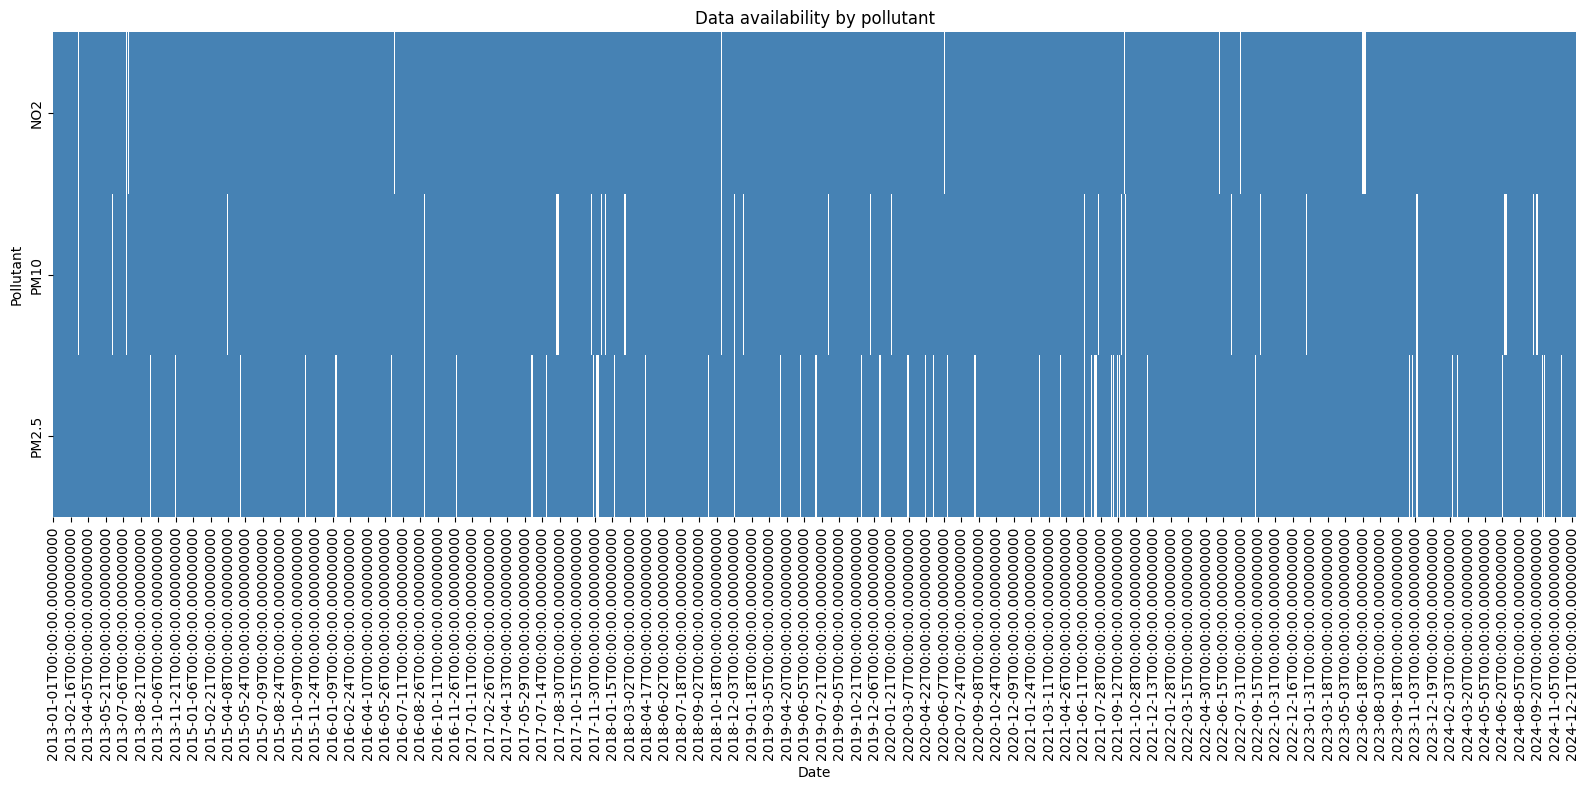

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a daily availability matrix
availability = (
    dataset.assign(available=1)
           .pivot(index="date",
                  columns="pollutant",
                  values="available")
           .fillna(0)
)

plt.figure(figsize=(16, 8))

sns.heatmap(
    availability.T,
    cmap=["white", "steelblue"],
    cbar=False,
    linewidths=0
)

plt.title("Data availability by pollutant")
plt.xlabel("Date")
plt.ylabel("Pollutant")

plt.tight_layout()
plt.show()

**---> Interpretation**

The availability heatmap shows that measurements are available for the vast majority of days throughout the study period. Missing observations are relatively sparse and mostly appear as isolated days rather than long continuous gaps.

Among the three pollutants, **NO₂** has the most complete time series, whereas **PM2.5** exhibits the highest number of missing observations, consistent with the completeness statistics reported above.

Although most missing observations outside 2014 appear as isolated days,
a complete one-year interruption is present in 2014 for all three pollutants.
This substantial gap must be explicitly considered during monthly aggregation,
trend analysis and forecasting.

In [10]:
# Ensure that the date column has datetime format
dataset["date"] = pd.to_datetime(dataset["date"])

print("Start date:", dataset["date"].min())
print("End date:", dataset["date"].max())

Start date: 2013-01-01 00:00:00
End date: 2024-12-31 00:00:00


In [11]:
# Extract the year from the observation date
dataset["year"] = dataset["date"].dt.year

# Define the complete expected range of years
expected_years = range(
    dataset["year"].min(),
    dataset["year"].max() + 1
)

# Count observations by pollutant and year
yearly_observation_counts = (
    dataset
    .groupby(["pollutant", "year"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=expected_years, fill_value=0)
)

yearly_observation_counts

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
pollutant,,,,,,,,,,,,
NO2,358,0,365,365,363,364,365,363,359,360,356,366
PM10,346,0,363,362,345,352,360,363,353,360,360,354
PM2.5,346,0,360,349,341,357,351,346,337,361,354,348


In [12]:
# Identify years with no observations for any pollutant
completely_missing_years = yearly_observation_counts.columns[
    yearly_observation_counts.sum(axis=0) == 0
].tolist()

print("Years with no observations for any pollutant:")
print(completely_missing_years)

Years with no observations for any pollutant:
[2014]


In [13]:
# Number of calendar days in each year
days_per_year = pd.Series(
    {
        year: (
            pd.Timestamp(f"{year}-12-31")
            - pd.Timestamp(f"{year}-01-01")
        ).days + 1
        for year in expected_years
    }
)

# Percentage of calendar days with available observations
yearly_temporal_completeness = (
    yearly_observation_counts
    .div(days_per_year, axis="columns")
    .mul(100)
    .round(2)
)

yearly_temporal_completeness

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
pollutant,,,,,,,,,,,,
NO2,98.08,0.0,100.00,99.73,99.45,99.73,100.00,99.18,98.36,98.63,97.53,100.00
PM10,94.79,0.0,99.45,98.91,94.52,96.44,98.63,99.18,96.71,98.63,98.63,96.72
PM2.5,94.79,0.0,98.63,95.36,93.42,97.81,96.16,94.54,92.33,98.90,96.99,95.08


**---> Interpretation of Yearly Temporal Completeness**

The yearly temporal completeness results confirm that the most substantial
temporal gap is the complete absence of observations in 2014 for all three
pollutants.

Outside 2014, the monitoring coverage is generally high. NO2 has the most
complete temporal coverage, remaining above approximately 97% in all available
years and reaching 100% in 2015, 2019, and 2024.

PM10 also shows relatively high coverage, ranging from approximately 94.5% to
99.5%. PM2.5 has slightly lower and more variable coverage, with the minimum
yearly completeness observed in 2021 at 92.33%.

Therefore, apart from the complete gap in 2014, the remaining missing
observations are relatively limited and scattered across individual days.

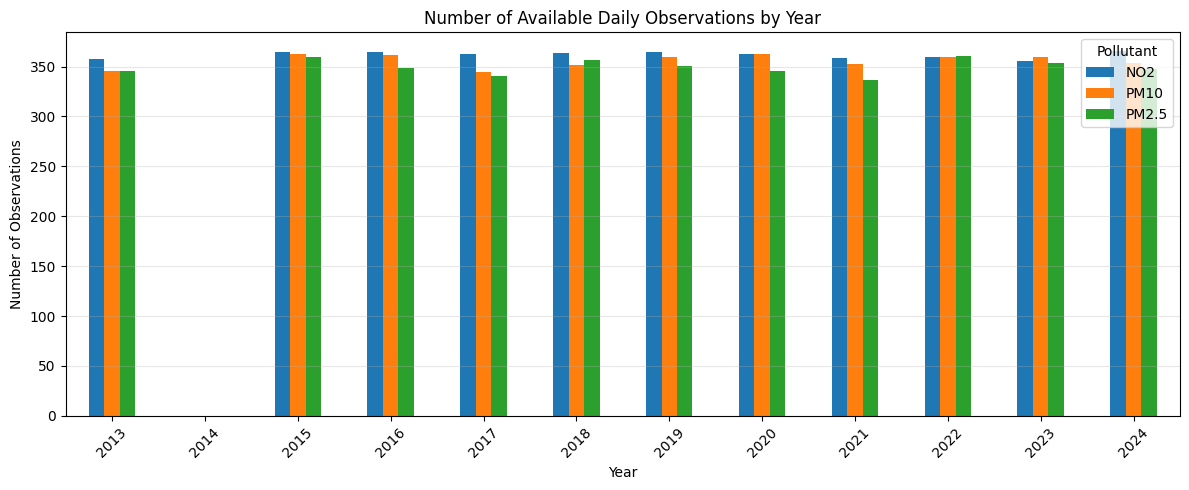

In [14]:
import matplotlib.pyplot as plt

ax = yearly_observation_counts.T.plot(
    kind="bar",
    figsize=(12, 5)
)

ax.set_title("Number of Available Daily Observations by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Observations")
ax.legend(title="Pollutant")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure:** Number of available daily observations for each pollutant by year.
The absence of bars in 2014 confirms that no measurements are available for
any of the three pollutants during that year.



---


### **3.1.3 Coverage of daily observations**

The quality of the daily measurements was evaluated using the variables `coverage_pct` and `n_obs`. The first indicates the percentage of expected measurements available for each day, while the second reports the number of raw observations used to compute the daily average. This analysis helps determine whether low-coverage days should be excluded before further analyses.





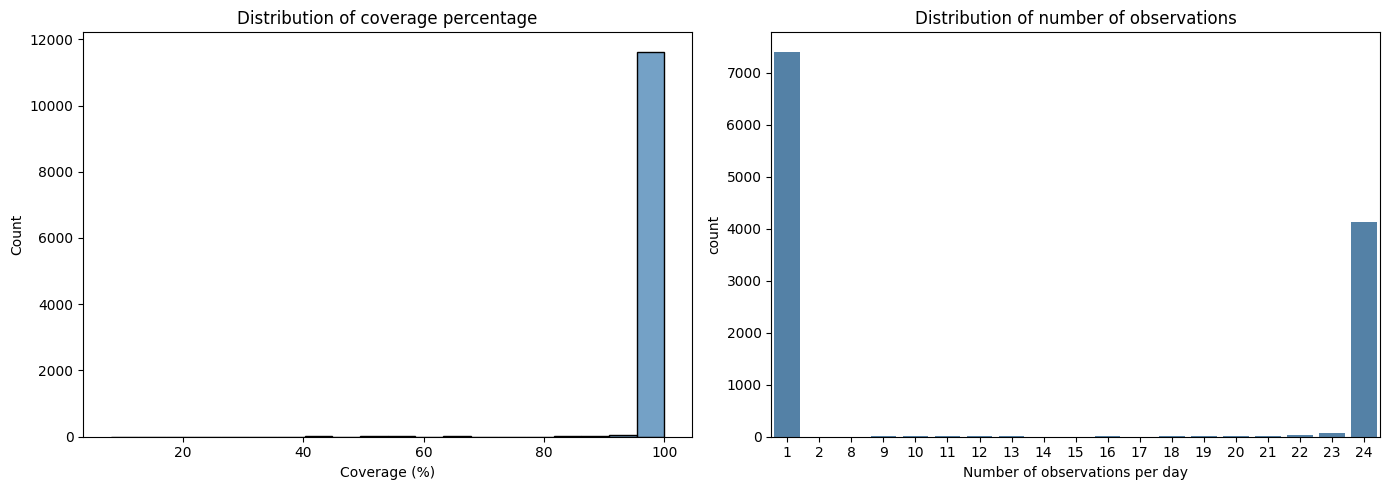


Coverage summary
count    11752.000000
mean        99.679459
std          3.561148
min          8.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: coverage_pct, dtype: float64

Days with coverage < 75%
51


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Distribution of coverage percentage
sns.histplot(
    dataset["coverage_pct"],
    bins=20,
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Distribution of coverage percentage")
axes[0].set_xlabel("Coverage (%)")

# Distribution of number of observations
sns.countplot(
    x="n_obs",
    data=dataset,
    ax=axes[1],
    color="steelblue"
)

axes[1].set_title("Distribution of number of observations")
axes[1].set_xlabel("Number of observations per day")

plt.tight_layout()
plt.show()

print("\nCoverage summary")
print(dataset["coverage_pct"].describe())

print("\nDays with coverage < 75%")
print((dataset["coverage_pct"] < 75).sum())

**---> Interpretation**

The distribution of `coverage_pct` indicates that the vast majority of daily observations have complete data coverage. The median and upper quartiles are equal to **100%**, while the average daily coverage is **99.68%**, demonstrating an overall high-quality dataset.

Only **51 observations** (approximately **0.43%** of the dataset) have a coverage below **75%**. Since these represent only a very small fraction of the data, a filtering threshold of **coverage_pct ≥ 75%** will be adopted before model training. This removes only a negligible number of observations while ensuring that daily averages are computed from sufficiently complete measurements.

The distribution of `n_obs` reveals two dominant groups: days with **24 observations**, corresponding to hourly NO₂ measurements aggregated to daily means, and days with **1 observation**, corresponding to pollutants that are already provided at daily resolution (PM10 and PM2.5).






---


**Days with low data coverage:**


To identify potentially unreliable daily averages, observations with a coverage below 75% were extracted and inspected. This allows us to verify whether these observations are isolated events or represent systematic quality issues.

In [16]:
# Days with coverage below 75%

low_coverage = (
    dataset[dataset["coverage_pct"] < 75]
    .sort_values(["date", "pollutant"])
    .reset_index(drop=True)
)

print(f"Number of low-coverage observations: {len(low_coverage)}")

low_coverage[
    [
        "date",
        "pollutant",
        "coverage_pct",
        "n_obs",
        "instrument"
    ]
]

Number of low-coverage observations: 51


,date,pollutant,coverage_pct,n_obs,instrument
0,2013-03-07,NO2,62.0,15,chemi
1,2013-03-11,NO2,54.0,13,chemi
2,2013-07-15,NO2,38.0,9,chemi
3,2013-07-18,NO2,54.0,13,chemi
4,2013-07-22,NO2,38.0,9,chemi
5,2015-04-20,NO2,42.0,10,chemi
6,2015-04-21,NO2,42.0,10,chemi
7,2015-08-24,NO2,42.0,10,chemi
8,2015-08-25,NO2,42.0,10,chemi
9,2016-06-21,NO2,42.0,10,chemi


**---> Interpretation**

Inspection of the low-coverage observations shows that **all 51 days with coverage below 75% belong exclusively to the NO₂ series**. This is expected because NO₂ is measured at hourly resolution, whereas PM10 and PM2.5 are already provided as daily measurements and therefore always have a coverage of 100%.

The low-coverage days are scattered throughout the monitoring period rather than concentrated within a specific year or season, suggesting that they are isolated measurement issues rather than prolonged monitoring interruptions.

Since these observations represent only a very small proportion of the dataset and are based on incomplete hourly measurements, they will be excluded before model training by applying a minimum daily coverage threshold of **75%**.



---


### **3.1.4 Applying the coverage filter**

Based on the previous analysis, observations with a daily coverage below 75% were excluded. This threshold removes only a very small number of low-quality observations (51 records, corresponding to approximately 0.43% of the dataset) while preserving the vast majority of the available measurements.

In [17]:
# Create the filtered dataset

dataset_filtered = (
    dataset[dataset["coverage_pct"] >= 75]
    .copy()
)

# Convert pollutant concentration values to numeric

dataset_filtered["value"] = pd.to_numeric(
    dataset_filtered["value"],
    errors="coerce"
)


print("Original dataset:", dataset.shape)
print("Filtered dataset:", dataset_filtered.shape)

print("\nRemoved observations:",
      len(dataset) - len(dataset_filtered))

Original dataset: (11752, 8)
Filtered dataset: (11701, 8)

Removed observations: 51


In [18]:
dataset_filtered["value"].dtype

dtype('float64')



---
### **3.1.5 Verified and provisional observations**

The proportion of officially verified measurements was examined to determine whether provisional observations are present in the dataset. This step is important because recently collected environmental data are sometimes published before undergoing the official validation process.


In [19]:
# Verification status

print(dataset_filtered["verified_share"].describe())

print("\nUnique values:")
print(dataset_filtered["verified_share"].value_counts().sort_index())

count    11701.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: verified_share, dtype: float64

Unique values:
verified_share
1.0    11701
Name: count, dtype: int64


In [20]:
# Check whether provisional observations exist

provisional = dataset_filtered[
    dataset_filtered["verified_share"] < 1
]

print("Number of provisional observations:", len(provisional))

provisional.head(20)

Number of provisional observations: 0


,date,pollutant,value,n_obs,verified_share,instrument,coverage_pct,year


**---> Interpretation**

All observations in the filtered dataset are **officially verified**, as indicated by a `verified_share` equal to **1.0** for every record. No provisional observations are present.

Therefore, no additional filtering based on the verification status is required, and the entire filtered dataset can be used for the subsequent exploratory analyses and forecasting models without concerns regarding data validation.

### **3.1.6 Instrument Consistency and Duplicate Timestamps**

The consistency of the measurement instruments was examined for each pollutant.
This analysis aims to identify possible instrument changes, overlapping
measurement periods and duplicated timestamps, since these issues may introduce
artificial changes or inconsistencies in the pollutant time series.

In [21]:
# Number of observations associated with each instrument and pollutant

instrument_summary = (
    data
    .groupby(["pollutant", "instrument"])
    .agg(
        first_observation=("Start", "min"),
        last_observation=("Start", "max"),
        number_of_observations=("Start", "size")
    )
    .reset_index()
    .sort_values(["pollutant", "first_observation"])
)

instrument_summary

,pollutant,instrument,first_observation,last_observation,number_of_observations
0,NO2,chemi,2013-01-01,2024-12-31 23:00:00,94682
1,PM10,BETA,2013-01-01,2024-12-31 00:00:00,3918
2,PM2.5,BETA,2013-01-01,2024-12-31 00:00:00,12059


In [22]:
# Check duplicated timestamps for each pollutant

duplicates = (
    data
    .groupby(["pollutant", "Start"])
    .size()
    .reset_index(name="count")
)

duplicates = duplicates[duplicates["count"] > 1]

duplicates

,pollutant,Start,count


In [23]:
# Number of duplicated timestamps

print(f"Duplicated timestamps: {len(duplicates)}")

Duplicated timestamps: 0


**---> Interpretation**

Only one measurement instrument was used for each pollutant throughout the entire monitoring period.

- **NO₂** was consistently measured using the **chemi** instrument.
- **PM10** and **PM2.5** were consistently measured using the **BETA** instrument.

No instrument replacements or overlapping measurement periods were identified. Consequently, no artificial level shifts caused by changes in measurement equipment are expected in the time series.

Furthermore, no duplicated timestamps were detected for any pollutant. This indicates that each observation corresponds to a unique measurement time and that the dataset does not contain duplicated records that could bias the subsequent analyses.

## **3.2 Distribution and Outliers**

The distributions of PM10, PM2.5 and NO₂ concentrations were explored using histograms. Examining the shape of each distribution helps identify skewness, heavy tails and potential deviations from normality, which are important considerations before applying forecasting models or statistical transformations.

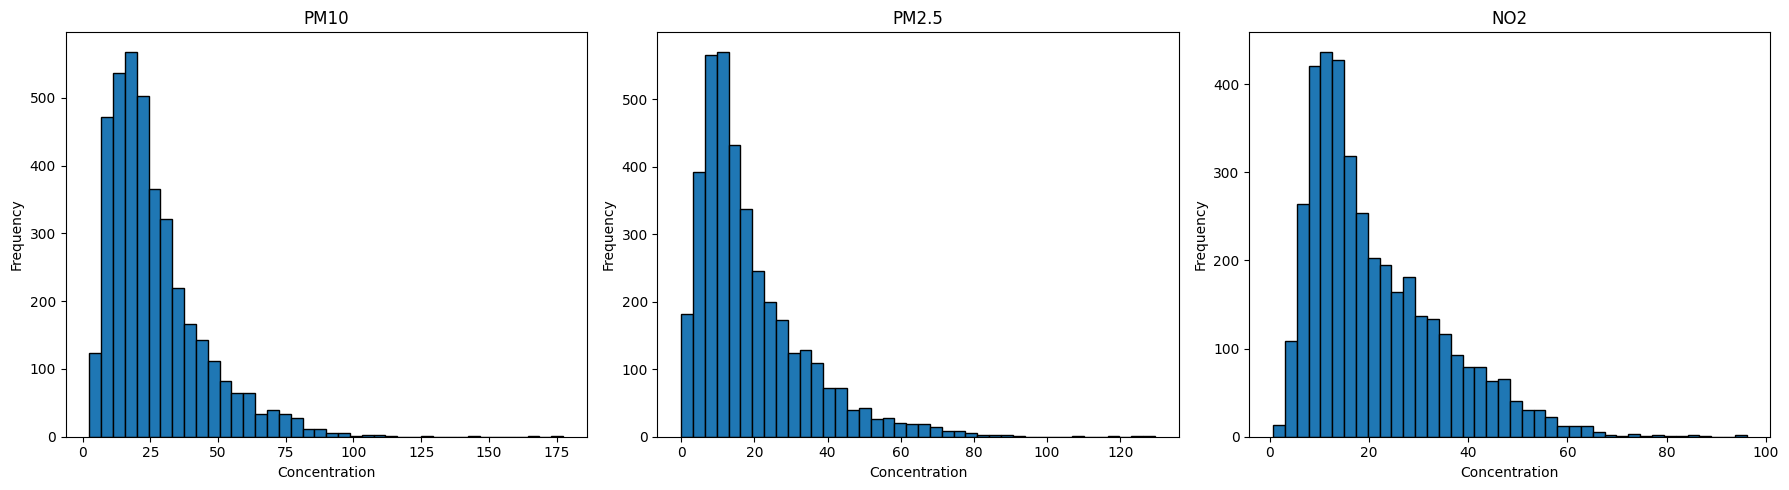

In [24]:
import matplotlib.pyplot as plt

pollutants = ["PM10", "PM2.5", "NO2"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, pollutant in zip(axes, pollutants):

    subset = dataset_filtered[
        dataset_filtered["pollutant"] == pollutant
    ]

    ax.hist(
        subset["value"],
        bins=40,
        edgecolor="black"
    )

    ax.set_title(pollutant)
    ax.set_xlabel("Concentration")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**---> Interpretation**

The histograms indicate that the distributions of all three pollutants are **positively skewed** rather than normally distributed.

PM10 and PM2.5 exhibit pronounced right tails, with most observations concentrated at relatively low concentrations and a small number of substantially larger values. NO₂ shows a similar pattern, although its distribution appears slightly less skewed.

These results suggest that extreme pollution episodes occur infrequently but contribute to long right tails in the distributions. The observed skewness indicates that a logarithmic transformation may be beneficial for some statistical analyses or forecasting models. However, the decision will be confirmed after examining boxplots and numerical skewness statistics.

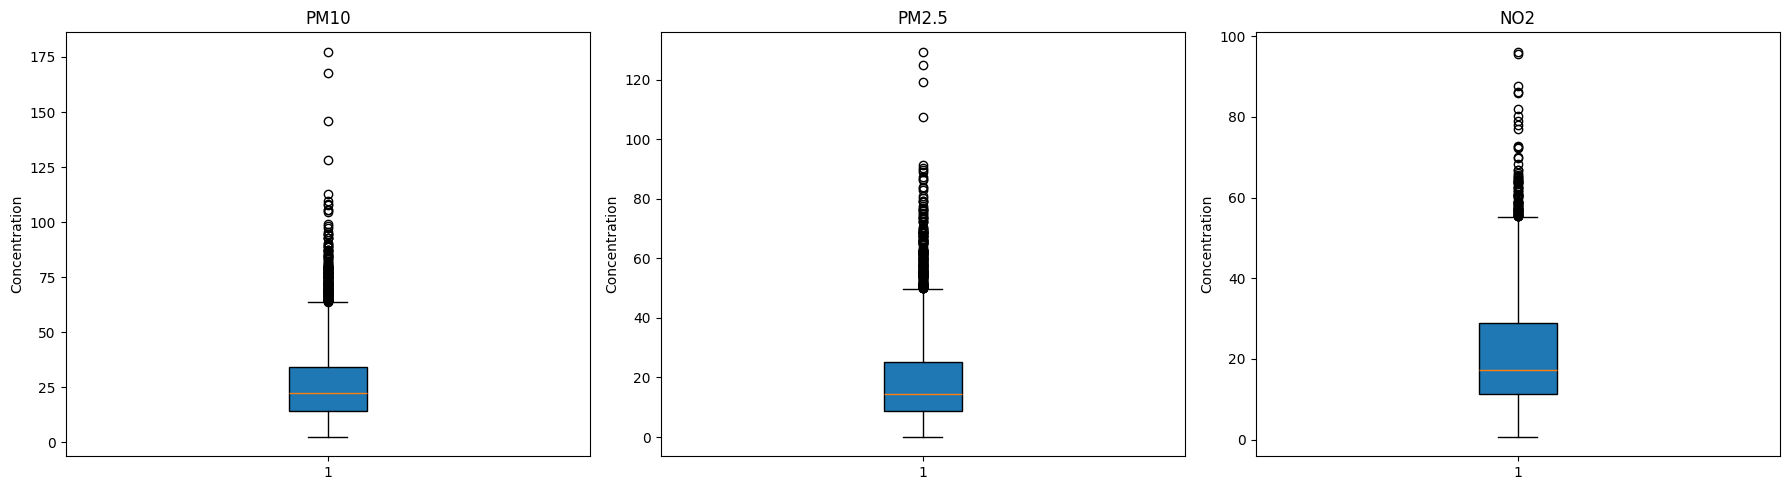

In [25]:
import matplotlib.pyplot as plt

pollutants = ["PM10", "PM2.5", "NO2"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, pollutant in zip(axes, pollutants):

    subset = dataset_filtered[
        dataset_filtered["pollutant"] == pollutant
    ]

    ax.boxplot(
        subset["value"],
        vert=True,
        patch_artist=True
    )

    ax.set_title(pollutant)
    ax.set_ylabel("Concentration")

plt.tight_layout()
plt.show()

In [26]:
# Descriptive statistics by pollutant

distribution_summary = (
    dataset_filtered
    .groupby("pollutant")["value"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Max="max",
        Skewness="skew"
    )
)

# Kurtosis separately
distribution_summary["Kurtosis"] = (
    dataset_filtered
    .groupby("pollutant")["value"]
    .apply(lambda x: x.kurt())
)

distribution_summary = distribution_summary.round(2)

distribution_summary

,Count,Mean,Median,Std,Min,Q1,Q3,Max,Skewness,Kurtosis
pollutant,,,,,,,,,,
NO2,3933,21.29,17.18,13.42,0.65,11.19,28.83,96.16,1.21,1.51
PM10,3918,26.74,22.27,17.59,2.45,14.21,34.09,177.42,1.71,4.90
PM2.5,3850,19.03,14.40,15.01,0.00,8.70,25.20,129.50,1.77,4.44


**---> Interpretation**

The descriptive statistics confirm the observations obtained from the histograms and boxplots.

For all three pollutants, the **mean exceeds the median**, indicating positively skewed distributions. The calculated skewness values are **1.21** for NO₂, **1.71** for PM10 and **1.77** for PM2.5, confirming substantial right-skewness, particularly for the particulate pollutants.

The boxplots reveal numerous high-value observations beyond the upper whiskers. These observations are consistent with occasional episodes of elevated air pollution and are therefore considered plausible environmental events rather than measurement errors. Consequently, they were retained in the dataset.

The positive kurtosis values, especially for PM10 (4.90) and PM2.5 (4.40), indicate heavier tails than a normal distribution, suggesting the presence of extreme pollution episodes.

Overall, the distributions are clearly non-normal. A logarithmic transformation could reduce skewness and stabilize the variance if required by specific statistical models. However, no transformation is applied at this stage; its usefulness will be evaluated later during the forecasting phase.

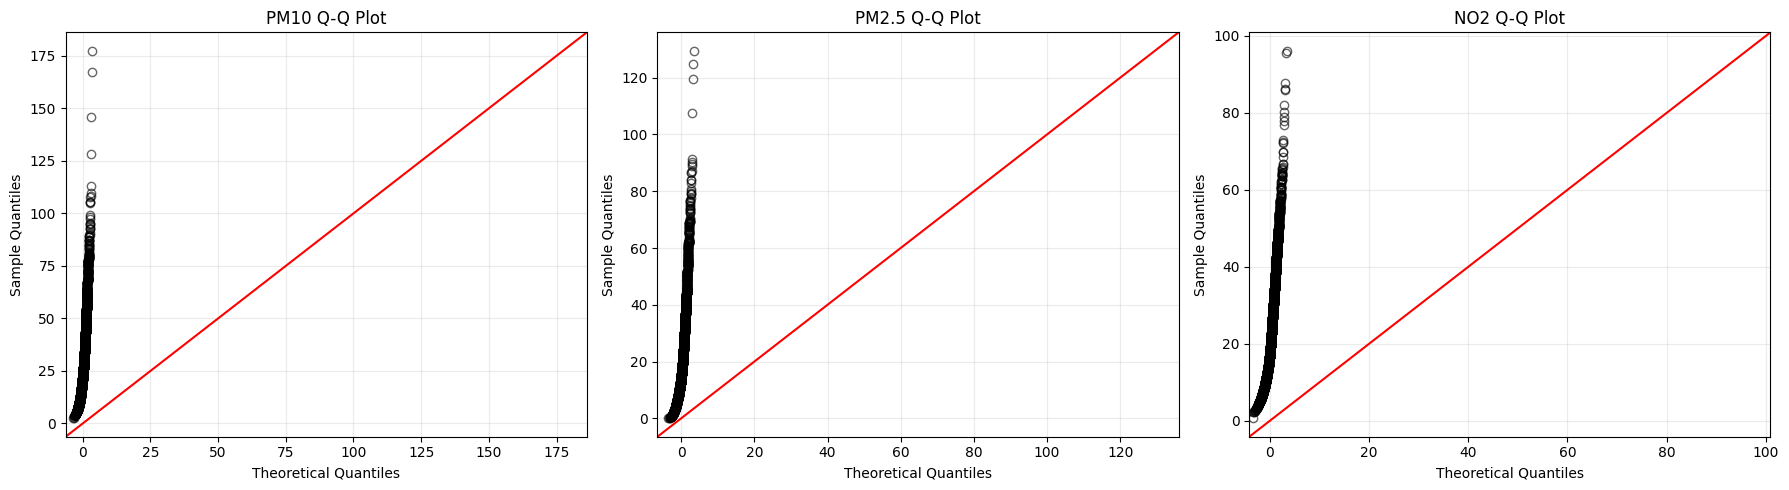

In [27]:
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot

pollutants = ["PM10", "PM2.5", "NO2"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pollutant in zip(axes, pollutants):

    subset = (
        dataset_filtered.loc[
            dataset_filtered["pollutant"] == pollutant,
            "value"
        ]
        .dropna()
        .astype(float)
        .to_numpy()
    )

    qqplot(
        subset,
        line="45",
        ax=ax,
        marker="o",
        markerfacecolor="none",
        markeredgecolor="black",
        alpha=0.6
    )

    ax.set_title(f"{pollutant} Q-Q Plot")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**---> Interpretation**

The Q-Q plots provide additional evidence that none of the pollutant distributions follows a normal distribution.

If the observations were normally distributed, the points would approximately follow the reference line. Instead, all three pollutants exhibit substantial departures from the line, particularly in the upper quantiles, confirming the presence of pronounced right tails and extreme values.

The deviation is strongest for PM10 and PM2.5, which is consistent with their higher skewness and kurtosis values. Although NO₂ also departs from normality, its deviation is comparatively smaller.

The agreement between the histograms, boxplots, descriptive statistics and Q-Q plots provides strong evidence that the pollutant concentrations are positively skewed and non-normal.

## **3.3 Temporal Structure**

### **3.3.1 Daily time series**

The daily concentrations of PM10, PM2.5 and NO₂ were plotted over the entire monitoring period (2013–2024). This visualization provides an overview of the temporal evolution of each pollutant and helps identify long-term trends, seasonal fluctuations and extreme pollution events.

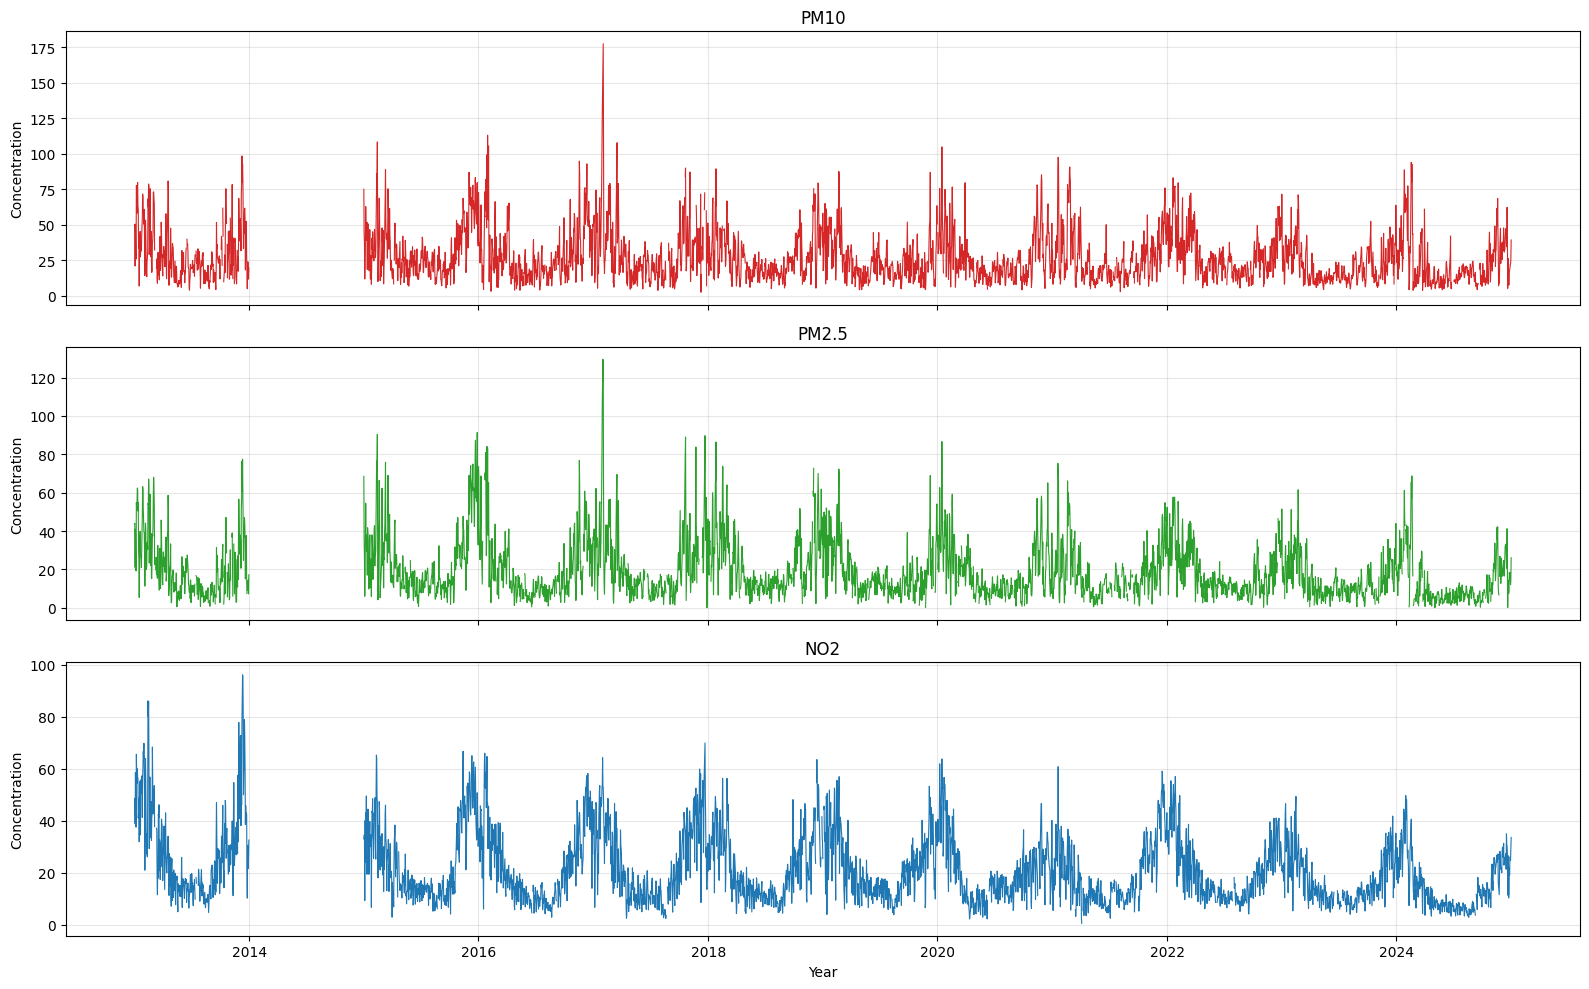

In [28]:
import matplotlib.pyplot as plt

colors = {
    "PM10":"tab:red",
    "PM2.5":"tab:green",
    "NO2":"tab:blue"
}

pollutants = ["PM10", "PM2.5", "NO2"]

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, pollutant in zip(axes, pollutants):


    subset = (
    dataset_filtered[dataset_filtered["pollutant"] == pollutant]
    .sort_values("date")
    .set_index("date")
      )

    # Create a complete daily index
    subset = subset.asfreq("D")

    ax.plot(
          subset.index,
          subset["value"],
          linewidth=0.8,
          color=colors[pollutant]
    )

    ax.set_title(pollutant)
    ax.set_ylabel("Concentration")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Year")

plt.tight_layout()
plt.show()

**---> Interpretation**
The daily time series reveal strong temporal variability for all three pollutants, with frequent short-term fluctuations and occasional extreme pollution episodes.

A clear seasonal pattern is visible throughout the monitoring period: pollutant concentrations generally increase during the colder months and decrease during the summer. This behaviour is consistent across PM10, PM2.5 and NO₂.

The visualizations also confirm the complete absence of observations during 2014, which corresponds to the temporal gap previously identified during the data quality assessment. Apart from this missing year, the remaining gaps are relatively limited and do not prevent the identification of the overall seasonal behaviour.

Although a gradual reduction in concentrations appears to be present in the later years of the monitoring period, the substantial day-to-day variability makes long-term trends difficult to assess directly from the daily observations.

For this reason, monthly aggregation will be performed in the next step in order to reduce short-term noise and facilitate the analysis of long-term trends and seasonal behaviour.

### **3.3.2 Monthly Aggregation and Visualization**

Daily observations contain substantial short-term variability that may obscure long-term temporal patterns. To reduce this noise and facilitate the interpretation of seasonal and long-term behaviour, daily concentrations were aggregated into monthly mean values for each pollutant.

The monthly time series provide a smoother representation of air quality evolution and form the basis for the subsequent trend, seasonality and forecasting analyses.

In [29]:
# Monthly aggregation

monthly_data = (
    dataset_filtered
    .assign(month=lambda df: df["date"].dt.to_period("M"))
    .groupby(["pollutant", "month"], as_index=False)
    .agg(
        monthly_mean=("value", "mean"),
        observations=("value", "count")
    )
)

monthly_data["month"] = monthly_data["month"].dt.to_timestamp()

monthly_data.head()

,pollutant,month,monthly_mean,observations
0,NO2,2013-01-01,52.067984,31
1,NO2,2013-02-01,47.872467,28
2,NO2,2013-03-01,33.458010,26
3,NO2,2013-04-01,23.868381,30
4,NO2,2013-05-01,14.776229,31


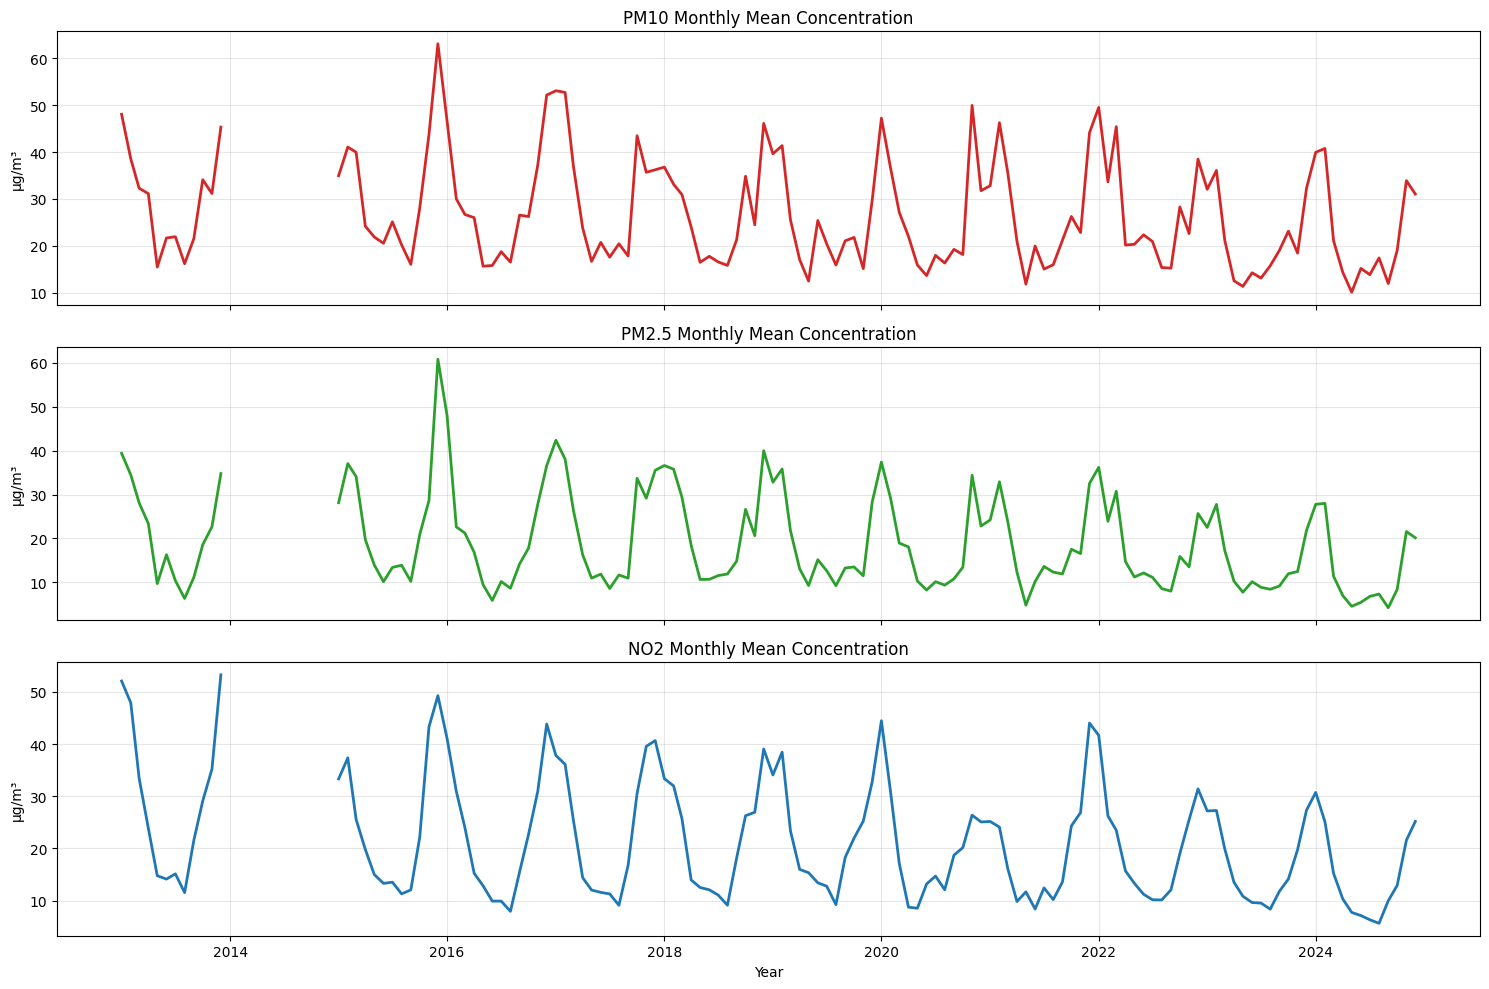

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

colors = {
    "PM10":"tab:red",
    "PM2.5":"tab:green",
    "NO2":"tab:blue"
}

pollutants = ["PM10", "PM2.5", "NO2"]

for ax, pollutant in zip(axes, pollutants):

    subset = (
        monthly_data[
            monthly_data["pollutant"] == pollutant
        ]
        .set_index("month")
        .asfreq("MS")          # Monthly Start Frequency
    )

    ax.plot(
        subset.index,
        subset["monthly_mean"],
        linewidth=2,
        color=colors[pollutant]
    )

    ax.set_title(f"{pollutant} Monthly Mean Concentration")
    ax.set_ylabel("µg/m³")
    ax.grid(alpha=0.3)

plt.xlabel("Year")
plt.tight_layout()
plt.show()

**--->  Interpretation**

The monthly aggregation substantially reduces the short-term variability observed in the daily time series, making the seasonal behaviour of the pollutants considerably easier to interpret.

A clear annual seasonal cycle is visible for all three pollutants. Concentrations generally increase during the winter months and decrease during the summer, reflecting the influence of domestic heating, meteorological conditions and atmospheric dispersion.

The seasonal pattern is particularly pronounced for **NO₂**, whose concentration exhibits regular winter peaks and summer minima throughout the monitoring period. PM10 and PM2.5 also display evident seasonality, although their monthly averages remain more irregular due to episodic pollution events.

The monthly series also confirms the complete absence of observations during 2014, which appears as a temporal gap in the monitoring record.

Regarding the long-term behaviour, pollutant concentrations appear to decrease slightly over the monitoring period, especially for NO₂ and PM2.5. Nevertheless, seasonal fluctuations remain the dominant source of variability, suggesting that a formal trend decomposition will be required to separate long-term changes from seasonal effects.

### **3.3.3 Seasonal Analysis**

To better investigate the annual seasonal behaviour, the monthly mean concentrations were grouped according to the calendar month. Averaging the observations from the same month across different years reduces the influence of individual pollution episodes and highlights the recurring seasonal cycle of each pollutant.

In [31]:
# Average concentration for each calendar month

seasonal_profile = (
    monthly_data
    .assign(calendar_month=lambda df: df["month"].dt.month)
    .groupby(
        ["pollutant", "calendar_month"],
        as_index=False
    )
    .agg(
        mean_concentration=("monthly_mean", "mean"),
        std_concentration=("monthly_mean", "std")
    )
)

seasonal_profile.head()

,pollutant,calendar_month,mean_concentration,std_concentration
0,NO2,1,36.437174,7.932074
1,NO2,2,32.373002,7.112847
2,NO2,3,22.670470,5.289513
3,NO2,4,14.675414,4.394533
4,NO2,5,12.245328,2.479471


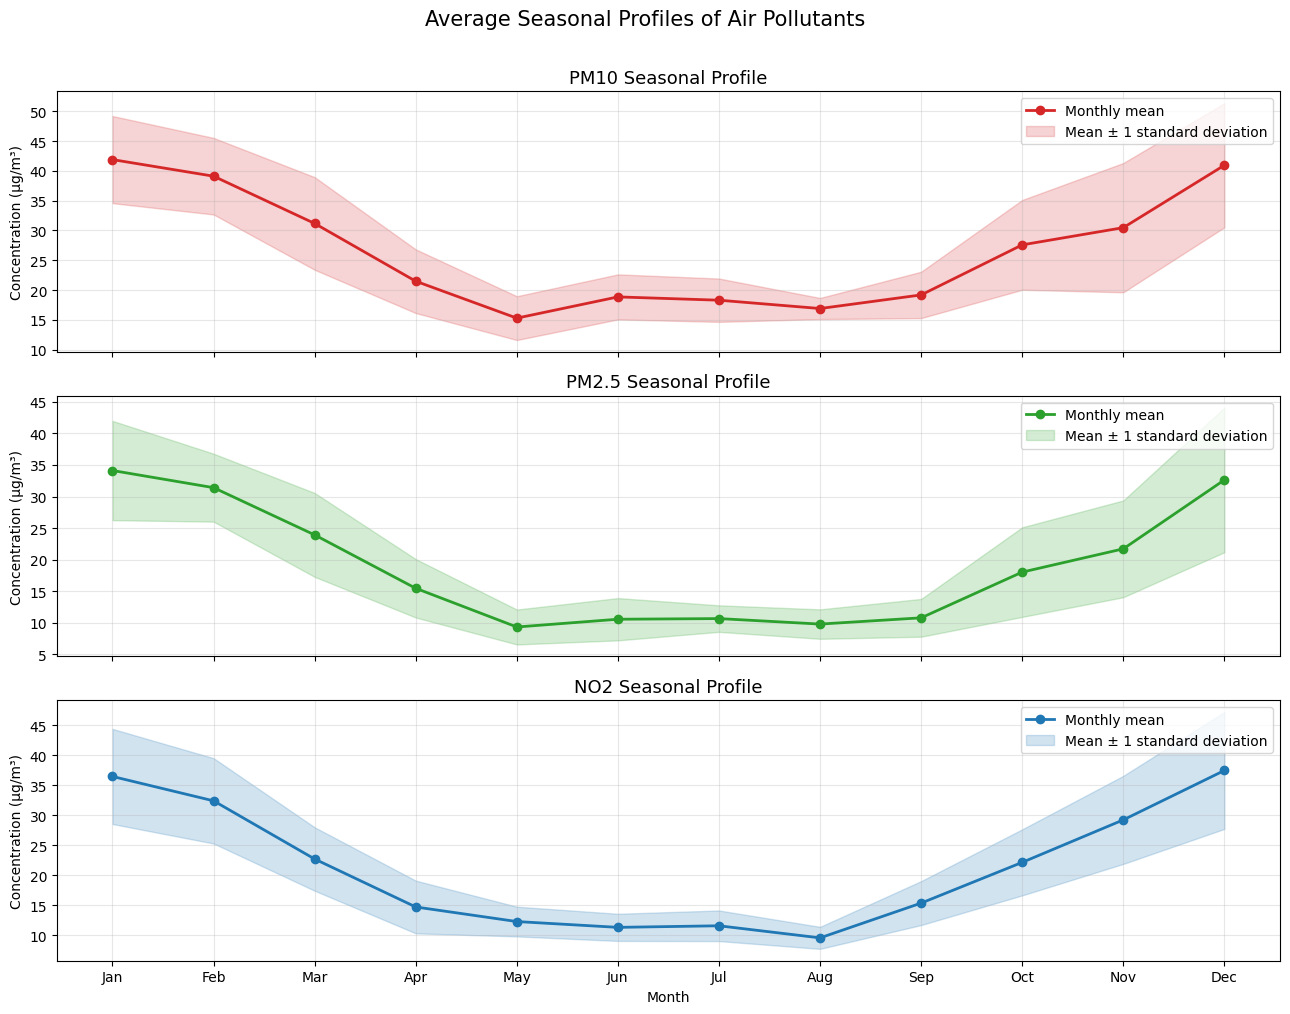

In [32]:
# Month labels for the x-axis

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]


# Define a different color for each pollutant

colors = {
    "PM10": "tab:red",
    "PM2.5": "tab:green",
    "NO2": "tab:blue"
}


# Create three vertically aligned plots

fig, axes = plt.subplots(
    3,
    1,
    figsize=(13, 10),
    sharex=True
)


# Order in which pollutants will be displayed

pollutants = ["PM10", "PM2.5", "NO2"]


# Create one seasonal profile for each pollutant

for ax, pollutant in zip(axes, pollutants):

    # Select the seasonal data for the current pollutant
    # and arrange the months from January to December

    subset = (
        seasonal_profile[
            seasonal_profile["pollutant"] == pollutant
        ]
        .sort_values("calendar_month")
    )


    # Convert pandas Series to NumPy arrays

    x = subset["calendar_month"].to_numpy()
    y = subset["mean_concentration"].to_numpy()
    std = subset["std_concentration"].to_numpy()


    # Plot the average concentration for each month

    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        color=colors[pollutant],
        label="Monthly mean"
    )


    # Add the mean ± one standard deviation area

    ax.fill_between(
        x,
        y - std,
        y + std,
        color=colors[pollutant],
        alpha=0.20,
        label="Mean ± 1 standard deviation"
    )


    # Add title and axis label

    ax.set_title(
        f"{pollutant} Seasonal Profile",
        fontsize=13
    )

    ax.set_ylabel(
        "Concentration (µg/m³)"
    )


    # Add a light grid

    ax.grid(
        alpha=0.30
    )


    # Add legend

    ax.legend(
        loc="upper right"
    )


# Add month names to the final subplot

axes[-1].set_xticks(
    range(1, 13)
)

axes[-1].set_xticklabels(
    month_labels
)

axes[-1].set_xlabel(
    "Month"
)


# Add an overall title for the complete figure

fig.suptitle(
    "Average Seasonal Profiles of Air Pollutants",
    fontsize=15,
    y=1.01
)


# Improve spacing between plots

plt.tight_layout()


# Display the figure

plt.show()

**Interpretation --->**

The seasonal profiles reveal a pronounced annual cycle for all three pollutants. Average concentrations are highest during the winter months (December–February) and gradually decrease throughout spring, reaching their minimum values during late spring and summer before increasing again in autumn.

PM10 exhibits the highest average concentrations during winter, followed by PM2.5, while NO₂ shows a similar seasonal pattern with slightly lower concentrations during the warm season. This behaviour is consistent with increased domestic heating, less favourable atmospheric dispersion conditions, and more frequent temperature inversions during winter. Conversely, higher temperatures, stronger solar radiation, and enhanced atmospheric mixing during summer contribute to lower pollutant concentrations.

The shaded areas represent one standard deviation around the monthly mean. Variability is noticeably larger during winter months, indicating greater year-to-year fluctuations associated with episodic pollution events and varying meteorological conditions. Summer months show substantially lower variability, suggesting more stable air quality conditions across different years.

Overall, the results confirm a strong and recurring annual seasonal pattern for all pollutants, motivating the application of formal time-series decomposition techniques in the following sections.

### **3.3.4 Long-Term Trend Analysis**

To investigate the long-term evolution of pollutant concentrations, a 12-month rolling mean was applied to the monthly time series. This smoothing window covers one complete annual cycle and reduces the influence of short-term fluctuations and recurring seasonal effects, allowing the underlying long-term trend to be more clearly observed.

In [33]:
# Create a 12-month rolling mean for each pollutant

monthly_trend = (
    monthly_data
    .sort_values(["pollutant", "month"])
    .copy()
)

monthly_trend["rolling_mean_12m"] = (
    monthly_trend
    .groupby("pollutant")["monthly_mean"]
    .transform(
        lambda series: series.rolling(
            window=12,
            min_periods=12
        ).mean()
    )
)

monthly_trend.head(15)

,pollutant,month,monthly_mean,observations,rolling_mean_12m
0,NO2,2013-01-01,52.067984,31,NaN
1,NO2,2013-02-01,47.872467,28,NaN
2,NO2,2013-03-01,33.458010,26,NaN
3,NO2,2013-04-01,23.868381,30,NaN
4,NO2,2013-05-01,14.776229,31,NaN
5,NO2,2013-06-01,14.132280,30,NaN
6,NO2,2013-07-01,15.135631,24,NaN
7,NO2,2013-08-01,11.547291,31,NaN
8,NO2,2013-09-01,21.553530,30,NaN
9,NO2,2013-10-01,29.095780,31,NaN


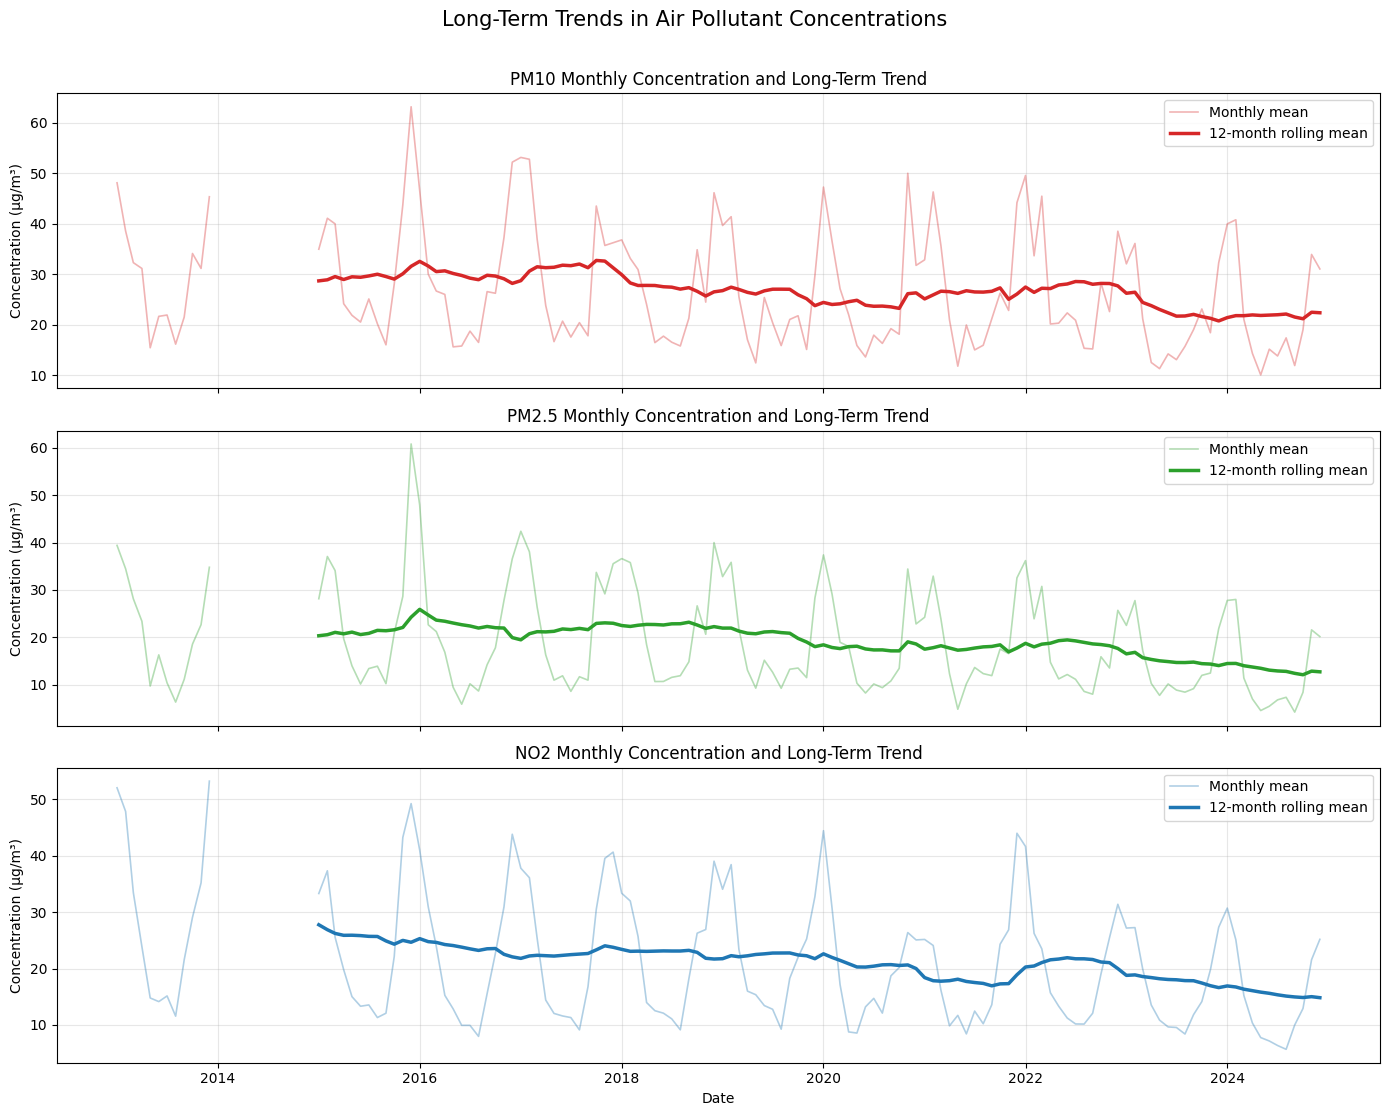

In [34]:
colors = {
    "PM10": "tab:red",
    "PM2.5": "tab:green",
    "NO2": "tab:blue"
}

pollutants = ["PM10", "PM2.5", "NO2"]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 11),
    sharex=True
)

for ax, pollutant in zip(axes, pollutants):

    subset = (
        monthly_trend[
            monthly_trend["pollutant"] == pollutant
        ]
        .sort_values("month")
        .set_index("month")
        .asfreq("MS")
    )

    ax.plot(
        subset.index,
        subset["monthly_mean"],
        color=colors[pollutant],
        alpha=0.35,
        linewidth=1.2,
        label="Monthly mean"
    )

    ax.plot(
        subset.index,
        subset["rolling_mean_12m"],
        color=colors[pollutant],
        linewidth=2.5,
        label="12-month rolling mean"
    )

    ax.set_title(
        f"{pollutant} Monthly Concentration and Long-Term Trend"
    )

    ax.set_ylabel(
        "Concentration (µg/m³)"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        loc="upper right"
    )

axes[-1].set_xlabel("Date")

fig.suptitle(
    "Long-Term Trends in Air Pollutant Concentrations",
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

The 12-month rolling mean highlights the underlying long-term evolution of pollutant concentrations after reducing the influence of short-term seasonal fluctuations. Despite substantial month-to-month variability, all three pollutants exhibit a gradual decline over the observation period.

PM10 shows the highest long-term concentrations throughout the study period, followed by PM2.5 and NO₂. Although temporary increases are visible around 2017–2018 and again near 2022, the overall tendency is downward. By the end of the observation period, all pollutants reach lower average concentrations than those observed at the beginning of the series.

The complete absence of observations during 2014 should be considered when interpreting the rolling averages around this period. Nevertheless, the overall decreasing trends remain evident and are consistent with the long-term reduction in air pollutant concentrations expected under progressively stricter environmental regulations and emission control measures.

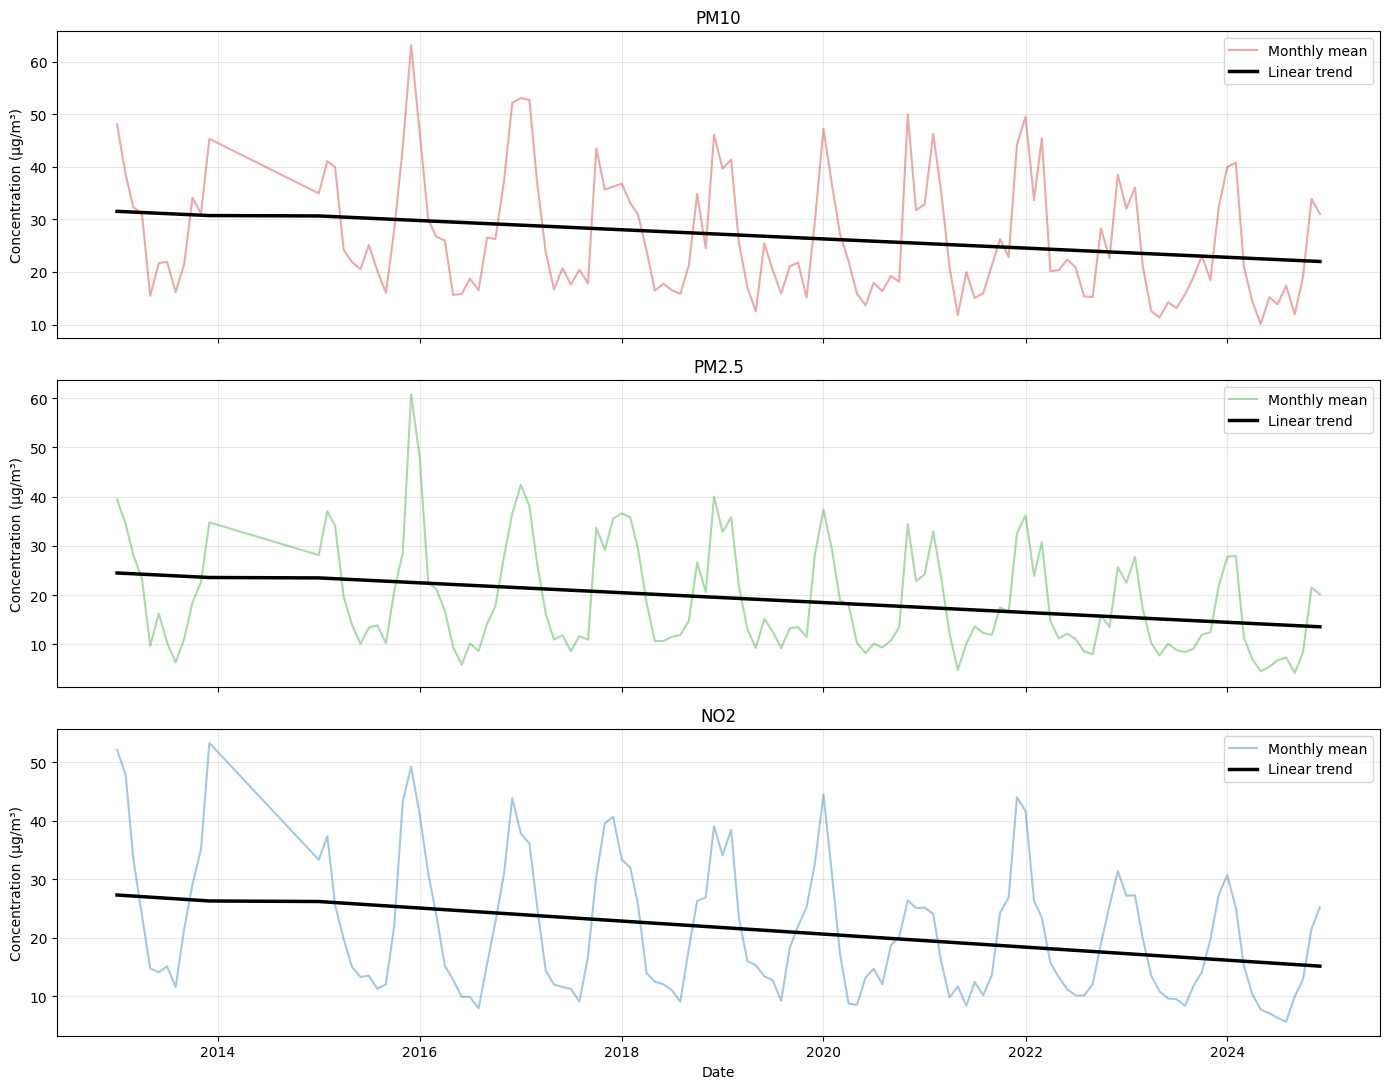

In [35]:
from scipy.stats import linregress

trend_results = []

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 11),
    sharex=True
)

colors = {
    "PM10": "tab:red",
    "PM2.5": "tab:green",
    "NO2": "tab:blue"
}

pollutants = ["PM10", "PM2.5", "NO2"]

for ax, pollutant in zip(axes, pollutants):

    subset = (
        monthly_data[
            monthly_data["pollutant"] == pollutant
        ]
        .sort_values("month")
        .copy()
    )

    # Numerical time index

    subset["time"] = range(len(subset))

    # Linear regression

    regression = linregress(
        subset["time"],
        subset["monthly_mean"]
    )

    # Fitted trend

    subset["linear_trend"] = (
        regression.intercept
        + regression.slope * subset["time"]
    )

    trend_results.append({

        "Pollutant": pollutant,

        "Slope (µg/m³/year)": regression.slope * 12,

        "R²": regression.rvalue**2,

        "p-value": regression.pvalue

    })

    ax.plot(
        subset["month"],
        subset["monthly_mean"],
        color=colors[pollutant],
        alpha=0.40,
        label="Monthly mean"
    )

    ax.plot(
        subset["month"],
        subset["linear_trend"],
        color="black",
        linewidth=2.5,
        label="Linear trend"
    )

    ax.set_title(
        pollutant
    )

    ax.set_ylabel(
        "Concentration (µg/m³)"
    )

    ax.grid(alpha=0.3)

    ax.legend()

axes[-1].set_xlabel("Date")

plt.tight_layout()

plt.show()

In [36]:
trend_results = (
    pd.DataFrame(trend_results)
    .round(3)
)

trend_results

,Pollutant,Slope (µg/m³/year),R²,p-value
0,PM10,-0.873,0.060,0.005
1,PM2.5,-1.001,0.087,0.001
2,NO2,-1.112,0.099,0.000


**---> Interpretation**

The fitted linear regression models indicate a statistically significant long-term decline in the concentrations of all three pollutants over the study period. The estimated annual decreases are approximately **0.87 µg/m³/year** for PM10, **1.00 µg/m³/year** for PM2.5, and **1.11 µg/m³/year** for NO₂.

Among the three pollutants, **NO₂** exhibits the largest annual decrease, followed by **PM2.5** and **PM10**. The p-values are below 0.01 for all pollutants, indicating that the observed downward trends are statistically significant.

However, the coefficients of determination (R² ≈ 0.06–0.10) are relatively low, showing that a simple linear trend explains only a small fraction of the total variability. This is expected because air pollutant concentrations are strongly influenced by seasonal cycles, meteorological conditions, and short-term emission fluctuations. Consequently, while the long-term decreasing trend is evident, additional analyses such as seasonal decomposition are required to separate the long-term trend from recurring seasonal patterns.

### **3.3.5 STL Decomposition**

To better understand the temporal structure of the monthly pollutant concentrations, Seasonal-Trend decomposition using Loess (STL) was applied to each time series. STL separates the observed series into three additive components:

- **Trend**, representing the long-term evolution of pollutant concentrations;
- **Seasonal**, representing recurring annual patterns;
- **Remainder**, representing irregular fluctuations that cannot be explained by either the trend or the seasonal cycle.

This decomposition provides a clearer understanding of the relative contribution of long-term changes, seasonality, and random variability, and helps determine whether the series is suitable for subsequent forecasting models.

In [37]:
from statsmodels.tsa.seasonal import STL

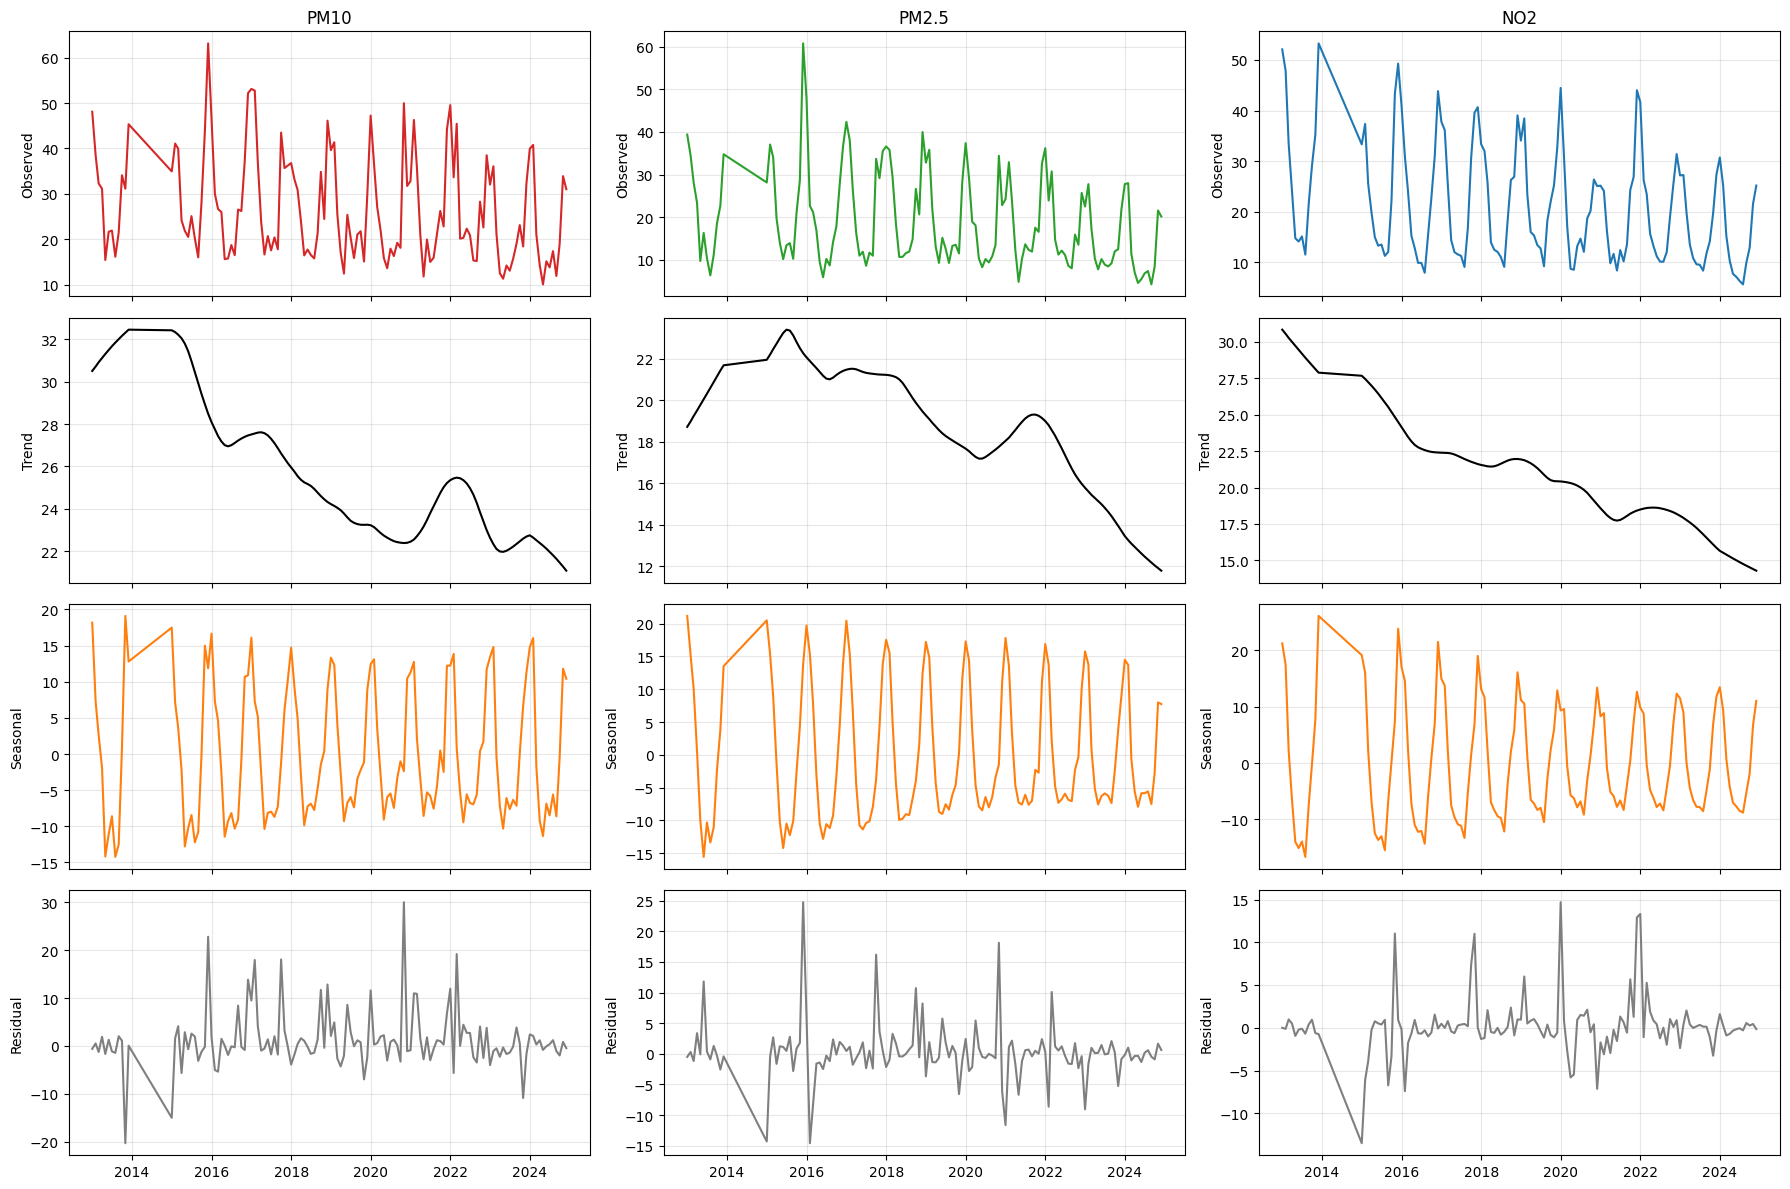

In [38]:
fig, axes = plt.subplots(
    4,
    3,
    figsize=(18, 12),
    sharex='col'
)

colors = {
    "PM10": "tab:red",
    "PM2.5": "tab:green",
    "NO2": "tab:blue"
}

pollutants = ["PM10", "PM2.5", "NO2"]

for col, pollutant in enumerate(pollutants):

    series = (
    monthly_data[
        monthly_data["pollutant"] == pollutant
    ]
    .set_index("month")["monthly_mean"]
    .asfreq("MS")
    .dropna()
)

    stl = STL(
        series,
        period=12,
        robust=True
    )

    result = stl.fit()

    axes[0, col].plot(
        series,
        color=colors[pollutant]
    )
    axes[0, col].set_title(pollutant)
    axes[0, col].set_ylabel("Observed")

    axes[1, col].plot(
        result.trend,
        color="black"
    )
    axes[1, col].set_ylabel("Trend")

    axes[2, col].plot(
        result.seasonal,
        color="tab:orange"
    )
    axes[2, col].set_ylabel("Seasonal")

    axes[3, col].plot(
        result.resid,
        color="tab:gray"
    )
    axes[3, col].set_ylabel("Residual")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

---> **Interpretation**

The STL decomposition confirms that the monthly concentrations of all three pollutants consist of three distinct components: a long-term trend, a strong seasonal cycle, and an irregular residual component.

The trend component shows a gradual decline throughout the study period for PM10, PM2.5, and NO₂, confirming the results obtained from the linear trend analysis. Among the three pollutants, NO₂ exhibits the most pronounced long-term decrease.

The seasonal component reveals a clear and highly regular annual pattern, with concentrations consistently reaching their highest levels during the colder months and their lowest levels during summer. This behaviour is consistent with increased domestic heating, less favourable atmospheric dispersion during winter, and improved pollutant dispersion during warmer months.

The residual component is centred around zero for most of the study period, indicating that the long-term trend and seasonal cycle explain a substantial part of the variability. The remaining spikes correspond to short-term events or irregular fluctuations that cannot be explained by either component.

Overall, the STL decomposition confirms that the series exhibit both a significant long-term trend and strong seasonality, characteristics that should be taken into account when selecting forecasting models.

### **3.3.6 Autocorrelation Analysis**

Before fitting forecasting models, it is useful to examine the temporal dependence of the monthly pollutant concentrations. Since the original monthly series exhibit a long-term trend, first-order differencing is applied to remove this trend and improve stationarity.

The autocorrelation function (ACF) and partial autocorrelation function (PACF) are then computed for the differenced monthly series. These plots help identify the dependence between observations at different time lags and provide useful guidance for selecting appropriate forecasting models, such as ARIMA.

In [39]:
monthly_diff = {}

for pollutant in ["PM10", "PM2.5", "NO2"]:

    series = (
        monthly_data[
            monthly_data["pollutant"] == pollutant
        ]
        .set_index("month")["monthly_mean"]
        .dropna()
    )

    monthly_diff[pollutant] = series.diff().dropna()

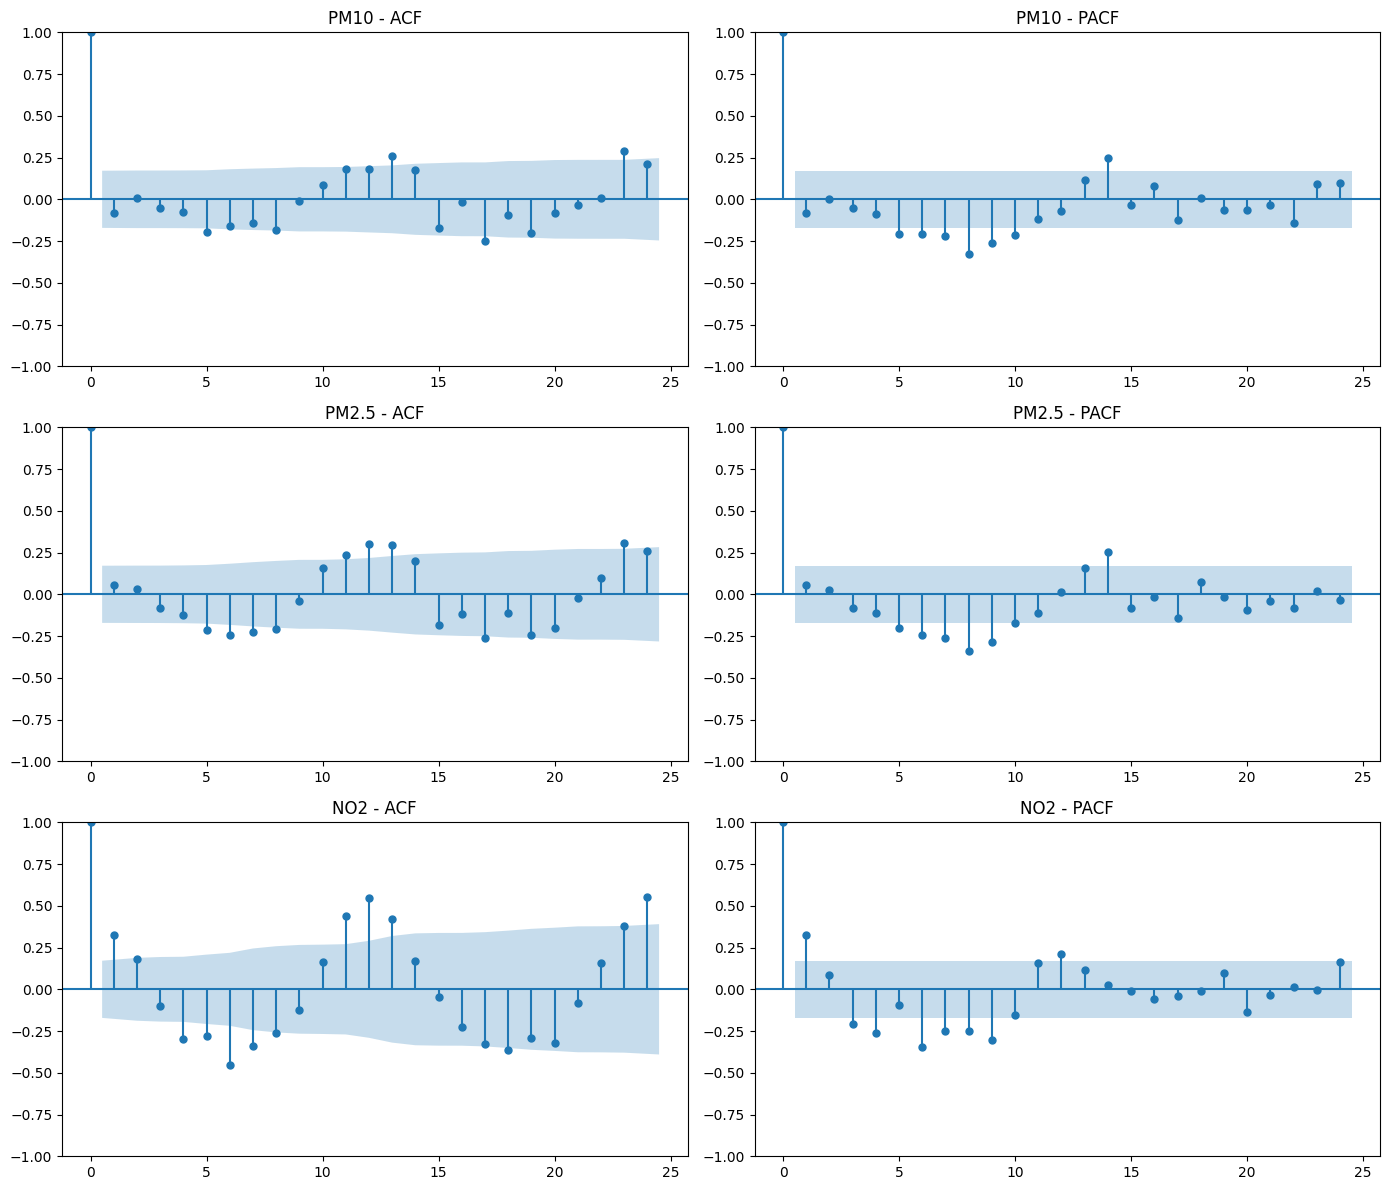

In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 12)
)

for i, pollutant in enumerate(["PM10", "PM2.5", "NO2"]):

    plot_acf(
        monthly_diff[pollutant],
        lags=24,
        ax=axes[i,0]
    )

    axes[i,0].set_title(f"{pollutant} - ACF")

    plot_pacf(
        monthly_diff[pollutant],
        lags=24,
        method="ywm",
        ax=axes[i,1]
    )

    axes[i,1].set_title(f"{pollutant} - PACF")

plt.tight_layout()

plt.show()

---> **Interpretation**

The ACF and PACF plots were computed for the first-differenced monthly series in order to remove the long-term trend and examine the remaining temporal dependence.

For all three pollutants, the autocorrelations decrease considerably after differencing, indicating that the long-term trend has been largely removed. However, significant autocorrelation remains at approximately **lag 12**, suggesting that an annual seasonal pattern is still present even after first-order differencing.

The PACF plots show only a few significant lags, while most higher-order lags fall within the confidence intervals. This suggests that the short-term dependence is relatively limited after differencing.

Overall, the results indicate that the monthly pollutant series are characterised by both short-term temporal dependence and a clear yearly seasonal component. Consequently, forecasting models should account for seasonality in addition to the long-term trend. These findings support the use of seasonal time-series models, such as SARIMA, rather than non-seasonal autoregressive models.

### **3.3.7 Stationarity Tests (ADF and KPSS)**

To formally assess stationarity, two complementary statistical tests were applied to the first-differenced monthly series.

The **Augmented Dickey-Fuller (ADF)** test evaluates the null hypothesis that the series contains a unit root (i.e., it is non-stationary). A small p-value leads to rejection of this hypothesis, suggesting that the series is stationary.

The **KPSS (Kwiatkowski–Phillips–Schmidt–Shin)** test adopts the opposite null hypothesis, namely that the series is stationary. Therefore, a large p-value indicates that stationarity cannot be rejected.

Using both tests together provides a more reliable assessment of whether the differenced series satisfies the stationarity assumption required by many time-series forecasting models.

In [41]:
from statsmodels.tsa.stattools import adfuller, kpss

stationarity_results = []

for pollutant in ["PM10", "PM2.5", "NO2"]:

    series = monthly_diff[pollutant]

    adf = adfuller(series)

    kpss_result = kpss(
        series,
        regression="c",
        nlags="auto"
    )

    stationarity_results.append({

        "Pollutant": pollutant,

        "ADF Statistic": adf[0],

        "ADF p-value": adf[1],

        "KPSS Statistic": kpss_result[0],

        "KPSS p-value": kpss_result[1]

    })

stationarity_results = (
    pd.DataFrame(stationarity_results)
    .round(4)
)

stationarity_results

/tmp/ipykernel_1024/1720824845.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/tmp/ipykernel_1024/1720824845.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/tmp/ipykernel_1024/1720824845.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


,Pollutant,ADF Statistic,ADF p-value,KPSS Statistic,KPSS p-value
0,PM10,-5.0224,0.0,0.0256,0.1
1,PM2.5,-4.9769,0.0,0.0235,0.1
2,NO2,-9.8316,0.0,0.0427,0.1


--->  **Interpretation**

The results of the ADF and KPSS tests consistently indicate that the first-differenced monthly series are stationary for all three pollutants.

For every pollutant, the **ADF test** returns a p-value smaller than 0.001, allowing the null hypothesis of a unit root to be rejected. This provides strong evidence that the differenced series are stationary.

Similarly, the **KPSS test** returns p-values equal to 0.10, meaning that the null hypothesis of stationarity cannot be rejected. Therefore, the KPSS results are fully consistent with the conclusions obtained from the ADF test.

Taken together, these two complementary tests confirm that first-order differencing successfully removes the long-term trend and produces stationary monthly series. Consequently, the stationarity assumption required by classical time-series forecasting models is satisfied, making the differenced series suitable for subsequent forecasting analyses.

---
# **🔮 Task 2 — Forecasting with at least three models**

Using the **monthly mean series** (after the quality filtering decided in the EDA), build and compare forecasting models for **each pollutant**.

### Requirements

1. **At least three different models**

2. **Honest evaluation — no leakage:**
   - use a **train/test split in time** (never random) and, better, a **rolling-origin backtest** (≥ 3 folds, forecast horizon of 12 months);
   - report **MAE, RMSE and MAPE (or sMAPE)** for every model and every pollutant in a single summary table;
   - explicitly compare each model against the seasonal-naive baseline.

3. **Final forecast:**

4. **Interpretation:** for each pollutant, answer in writing: *according to your forecast, will the annual mean at this station comply with the 2030 EU limit values?* (thresholds in Section 5). Discuss honestly the limits of such a long extrapolation (trend assumptions, instrument effects, policy changes not in the data).

> **Deliverable:** code + a metrics table + forecast plots + a short written conclusion per pollutant. Save the final forecasts to a file (e.g. `data/forecasts.parquet`) — the dashboard of Task 3 will read it.



---

# **4. Forecasting**

The objective of this task is to forecast monthly mean concentrations of PM10, PM2.5, and NO₂ and to compare multiple forecasting approaches under an honest time-based evaluation framework.

Four forecasting approaches are considered:

1. **Seasonal Naive**, used as the reference baseline;
2. **Linear Trend with Monthly Seasonal Effects**;
3. **Holt–Winters Exponential Smoothing (ETS)**;
4. **Seasonal ARIMA (SARIMA)**.

Model performance will be assessed using a rolling-origin backtest with three folds and a forecast horizon of 12 months. At each fold, models are trained only on observations occurring before the corresponding test period, thereby preventing information leakage.

The models will be compared using MAE, RMSE, and sMAPE. After selecting the most suitable model for each pollutant, final forecasts will be generated and saved for use in the Task 3 dashboard.

## **4.1 Preparing the Monthly Forecasting Series**

Forecasting models require observations to follow a regular monthly frequency. Since the dataset contains a complete interruption during 2014, simply removing the missing months would incorrectly treat observations before and after the gap as consecutive.

Therefore, the forecasting analysis is based on the continuous monthly period beginning after the 2014 interruption. This avoids artificial interpolation across an entire missing year and preserves the true temporal spacing of the observations.

In [42]:
# Pollutants included in the forecasting analysis
pollutants = ["PM10", "PM2.5", "NO2"]

forecast_series = {}

for pollutant in pollutants:

    # Extract the monthly mean series
    series = (
        monthly_data[
            monthly_data["pollutant"] == pollutant
        ]
        .set_index("month")["monthly_mean"]
        .sort_index()
        .asfreq("MS")
    )

    # Use the continuous period after the complete 2014 interruption
    series = series.loc["2015-01-01":]

    forecast_series[pollutant] = series

    print(f"{pollutant}")
    print(f"Start date: {series.index.min().date()}")
    print(f"End date:   {series.index.max().date()}")
    print(f"Number of months: {len(series)}")
    print(f"Missing months:   {series.isna().sum()}")
    print("-" * 40)

PM10
Start date: 2015-01-01
End date:   2024-12-01
Number of months: 120
Missing months:   0
----------------------------------------
PM2.5
Start date: 2015-01-01
End date:   2024-12-01
Number of months: 120
Missing months:   0
----------------------------------------
NO2
Start date: 2015-01-01
End date:   2024-12-01
Number of months: 120
Missing months:   0
----------------------------------------


## **4.2 Rolling-Origin Backtest**

To ensure an honest evaluation, forecasting models are assessed using a rolling-origin backtest instead of a random train/test split.

Three folds are used, each with a forecasting horizon of **12 months**. At every iteration, the training period expands while the test period always consists of the following 12 months. This evaluation strategy closely mimics real forecasting scenarios and prevents information leakage from future observations.

The same backtesting procedure is applied to all forecasting models, ensuring that their predictive performance can be fairly compared.

In [43]:
def rolling_origin_splits(series,
                          horizon=12,
                          folds=3):
    """
    Generate rolling-origin train/test splits.
    """

    splits = []

    total_length = len(series)

    first_train_end = (
        total_length
        - horizon * folds
    )

    for fold in range(folds):

        train_end = (
            first_train_end
            + fold * horizon
        )

        train = series.iloc[:train_end]

        test = series.iloc[
            train_end:
            train_end + horizon
        ]

        splits.append(
            (train, test)
        )

    return splits

In [44]:
for pollutant in pollutants:

    print("=" * 50)

    print(pollutant)

    splits = rolling_origin_splits(
        forecast_series[pollutant]
    )

    for i, (train, test) in enumerate(splits, start=1):

        print()

        print(f"Fold {i}")

        print(
            train.index.min().date(),
            "→",
            train.index.max().date()
        )

        print(
            test.index.min().date(),
            "→",
            test.index.max().date()
        )

PM10

Fold 1
2015-01-01 → 2021-12-01
2022-01-01 → 2022-12-01

Fold 2
2015-01-01 → 2022-12-01
2023-01-01 → 2023-12-01

Fold 3
2015-01-01 → 2023-12-01
2024-01-01 → 2024-12-01
PM2.5

Fold 1
2015-01-01 → 2021-12-01
2022-01-01 → 2022-12-01

Fold 2
2015-01-01 → 2022-12-01
2023-01-01 → 2023-12-01

Fold 3
2015-01-01 → 2023-12-01
2024-01-01 → 2024-12-01
NO2

Fold 1
2015-01-01 → 2021-12-01
2022-01-01 → 2022-12-01

Fold 2
2015-01-01 → 2022-12-01
2023-01-01 → 2023-12-01

Fold 3
2015-01-01 → 2023-12-01
2024-01-01 → 2024-12-01


## **4.3 Seasonal Naive Baseline**

As a reference model, a seasonal naïve forecast is used. This baseline assumes that the value for each month is equal to the observation recorded in the same month of the previous year.

For example, the forecast for January 2023 is simply the observed value from January 2022. Although simple, this baseline is difficult to outperform for strongly seasonal time series and therefore provides a meaningful benchmark for evaluating more sophisticated forecasting models.

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np


def smape(y_true, y_pred):

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    return np.mean(

        2 * np.abs(y_pred - y_true)

        /

        (np.abs(y_true) + np.abs(y_pred))

    ) * 100

In [46]:
baseline_results = []

for pollutant in pollutants:

    splits = rolling_origin_splits(
        forecast_series[pollutant]
    )

    for fold, (train, test) in enumerate(splits, start=1):

        forecast = train.iloc[-12:].values

        baseline_results.append({

            "Pollutant": pollutant,

            "Fold": fold,

            "Model": "Seasonal Naive",

            "MAE": mean_absolute_error(
                test,
                forecast
            ),

            "RMSE": np.sqrt(

                mean_squared_error(
                    test,
                    forecast
                )

            ),

            "sMAPE": smape(
                test,
                forecast
            )

        })

In [47]:
baseline_results = pd.DataFrame(
    baseline_results
)

baseline_results.round(3)

,Pollutant,Fold,Model,MAE,RMSE,sMAPE
0,PM10,1,Seasonal Naive,5.925,7.736,21.297
1,PM10,2,Seasonal Naive,8.034,10.253,33.223
2,PM10,3,Seasonal Naive,3.916,5.785,17.482
3,PM2.5,1,Seasonal Naive,5.030,5.896,30.104
4,PM2.5,2,Seasonal Naive,4.453,6.182,24.922
5,PM2.5,3,Seasonal Naive,3.749,4.412,35.360
6,NO2,1,Seasonal Naive,4.951,6.902,23.188
7,NO2,2,Seasonal Naive,3.551,5.109,17.412
8,NO2,3,Seasonal Naive,2.675,2.822,21.553


In [48]:
baseline_summary = (
    baseline_results
    .groupby(["Pollutant", "Model"], as_index=False)
    .agg(
        MAE=("MAE", "mean"),
        RMSE=("RMSE", "mean"),
        sMAPE=("sMAPE", "mean")
    )
)

baseline_summary = baseline_summary.round(3)

baseline_summary

,Pollutant,Model,MAE,RMSE,sMAPE
0,NO2,Seasonal Naive,3.725,4.944,20.717
1,PM10,Seasonal Naive,5.958,7.925,24.001
2,PM2.5,Seasonal Naive,4.410,5.497,30.129


## **4.4 Linear Trend with Monthly Seasonality**

The first forecasting model is a linear regression including both a long-term trend and monthly seasonal effects.

Time is represented as a continuous numerical variable to capture the long-term trend, while seasonality is modelled using monthly dummy variables. This simple statistical model serves as a stronger benchmark than the seasonal naïve approach while remaining fully interpretable.

In [49]:
from sklearn.linear_model import LinearRegression
import pandas as pd

In [50]:
def linear_trend_forecast(train, horizon=12):

    train_df = train.reset_index()

    train_df.columns = ["month", "y"]

    train_df["time"] = range(len(train_df))

    train_df["month_num"] = train_df["month"].dt.month.astype("category")

    X_train = pd.get_dummies(
        train_df[["time", "month_num"]],
        drop_first=True
    )

    model = LinearRegression()

    model.fit(X_train, train_df["y"])

    future = pd.DataFrame({
        "time": range(len(train_df), len(train_df) + horizon),
        "month": pd.date_range(
            train.index[-1] + pd.offsets.MonthBegin(),
            periods=horizon,
            freq="MS"
        )
    })

    future["month_num"] = future["month"].dt.month.astype("category")

    X_future = pd.get_dummies(
        future[["time", "month_num"]],
        drop_first=True
    )

    X_future = X_future.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    forecast = model.predict(X_future)

    return forecast

In [51]:
linear_results = []

for pollutant in pollutants:

    splits = rolling_origin_splits(
        forecast_series[pollutant]
    )

    for fold, (train, test) in enumerate(splits, start=1):

        forecast = linear_trend_forecast(train)

        linear_results.append({

            "Pollutant": pollutant,

            "Fold": fold,

            "Model": "Linear Trend",

            "MAE": mean_absolute_error(test, forecast),

            "RMSE": np.sqrt(mean_squared_error(test, forecast)),

            "sMAPE": smape(test, forecast)

        })

linear_results = pd.DataFrame(linear_results)

linear_results.round(3)

,Pollutant,Fold,Model,MAE,RMSE,sMAPE
0,PM10,1,Linear Trend,5.784,7.514,23.168
1,PM10,2,Linear Trend,4.590,5.627,20.774
2,PM10,3,Linear Trend,3.931,4.660,17.237
3,PM2.5,1,Linear Trend,4.359,5.109,28.167
4,PM2.5,2,Linear Trend,3.786,4.807,25.324
5,PM2.5,3,Linear Trend,3.247,4.303,25.374
6,NO2,1,Linear Trend,3.605,4.212,21.277
7,NO2,2,Linear Trend,3.130,4.141,16.948
8,NO2,3,Linear Trend,2.139,3.129,12.095


In [52]:
linear_summary = (
    linear_results
    .groupby(["Pollutant", "Model"], as_index=False)
    .agg(
        MAE=("MAE", "mean"),
        RMSE=("RMSE", "mean"),
        sMAPE=("sMAPE", "mean")
    )
)

linear_summary = linear_summary.round(3)

linear_summary

,Pollutant,Model,MAE,RMSE,sMAPE
0,NO2,Linear Trend,2.958,3.827,16.774
1,PM10,Linear Trend,4.768,5.933,20.393
2,PM2.5,Linear Trend,3.797,4.740,26.288


## **4.5 Holt–Winters Exponential Smoothing**

The second forecasting model is Holt–Winters exponential smoothing. This approach models the time series using three components: level, trend, and seasonality.

An additive trend and additive seasonal structure are used because pollutant concentrations fluctuate around a seasonal pattern whose absolute magnitude is reasonably stable over time. The seasonal period is set to 12 months.

Unlike the linear regression model, Holt–Winters gives greater weight to more recent observations, allowing the estimated level and trend to adapt gradually over time.

In [53]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing


def holt_winters_forecast(train, horizon=12):

    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    )

    fitted_model = model.fit(
        optimized=True
    )

    forecast = fitted_model.forecast(horizon)


    forecast = np.maximum(forecast, 0)




    return forecast

In [54]:
holt_winters_results = []

for pollutant in pollutants:

    splits = rolling_origin_splits(
        forecast_series[pollutant]
    )

    for fold, (train, test) in enumerate(splits, start=1):

        forecast = holt_winters_forecast(
            train,
            horizon=len(test)
        )

        holt_winters_results.append({

            "Pollutant": pollutant,

            "Fold": fold,

            "Model": "Holt-Winters",

            "MAE": mean_absolute_error(
                test,
                forecast
            ),

            "RMSE": np.sqrt(
                mean_squared_error(
                    test,
                    forecast
                )
            ),

            "sMAPE": smape(
                test,
                forecast
            )

        })

holt_winters_results = pd.DataFrame(
    holt_winters_results
)

holt_winters_results.round(3)

,Pollutant,Fold,Model,MAE,RMSE,sMAPE
0,PM10,1,Holt-Winters,5.784,7.514,23.168
1,PM10,2,Holt-Winters,4.584,5.624,20.750
2,PM10,3,Holt-Winters,3.931,4.660,17.237
3,PM2.5,1,Holt-Winters,4.362,5.113,28.183
4,PM2.5,2,Holt-Winters,3.786,4.807,25.323
5,PM2.5,3,Holt-Winters,3.245,4.302,25.355
6,NO2,1,Holt-Winters,3.605,4.212,21.277
7,NO2,2,Holt-Winters,3.130,4.141,16.949
8,NO2,3,Holt-Winters,4.019,4.374,63.964


In [55]:
train, test = rolling_origin_splits(
    forecast_series["NO2"]
)[2]







forecast = holt_winters_forecast(train)

comparison = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast
}, index=test.index)

comparison

,Actual,Forecast
month,,
2024-01-01,30.722954,25.400128
2024-02-01,25.099628,21.523723
2024-03-01,15.228109,12.363312
2024-04-01,10.330128,4.201118
2024-05-01,7.749185,2.528049
2024-06-01,7.144729,1.483214
2024-07-01,6.343665,1.781536
2024-08-01,5.666391,0.000000
2024-09-01,9.984412,5.289322


In [56]:
holt_winters_summary = (
    holt_winters_results
    .groupby(["Pollutant", "Model"], as_index=False)
    .agg(
        MAE=("MAE", "mean"),
        RMSE=("RMSE", "mean"),
        sMAPE=("sMAPE", "mean")
    )
)

holt_winters_summary = holt_winters_summary.round(3)

holt_winters_summary

,Pollutant,Model,MAE,RMSE,sMAPE
0,NO2,Holt-Winters,3.585,4.242,34.063
1,PM10,Holt-Winters,4.766,5.933,20.385
2,PM2.5,Holt-Winters,3.797,4.740,26.287


In [57]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


def sarima_forecast(train, horizon=12):

    model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False
    )

    forecast = fitted_model.forecast(
        steps=horizon
    )

    forecast = np.maximum(
        forecast,
        0
    )

    return forecast

In [58]:
sarima_results = []

for pollutant in pollutants:

    splits = rolling_origin_splits(
        forecast_series[pollutant]
    )

    for fold, (train, test) in enumerate(splits, start=1):

        forecast = sarima_forecast(
            train,
            horizon=len(test)
        )

        sarima_results.append({

            "Pollutant": pollutant,

            "Fold": fold,

            "Model": "SARIMA",

            "MAE": mean_absolute_error(
                test,
                forecast
            ),

            "RMSE": np.sqrt(
                mean_squared_error(
                    test,
                    forecast
                )
            ),

            "sMAPE": smape(
                test,
                forecast
            )

        })

sarima_results = pd.DataFrame(
    sarima_results
)

sarima_results.round(3)

,Pollutant,Fold,Model,MAE,RMSE,sMAPE
0,PM10,1,SARIMA,5.498,7.415,22.123
1,PM10,2,SARIMA,4.838,5.935,21.032
2,PM10,3,SARIMA,3.874,4.757,17.625
3,PM2.5,1,SARIMA,3.683,4.744,21.855
4,PM2.5,2,SARIMA,2.913,3.895,17.795
5,PM2.5,3,SARIMA,2.979,4.030,24.546
6,NO2,1,SARIMA,3.003,3.254,18.397
7,NO2,2,SARIMA,3.002,3.875,16.686
8,NO2,3,SARIMA,2.055,2.902,13.346


In [59]:
sarima_summary = (
    sarima_results
    .groupby(["Pollutant", "Model"], as_index=False)
    .agg(
        MAE=("MAE", "mean"),
        RMSE=("RMSE", "mean"),
        sMAPE=("sMAPE", "mean")
    )
)

sarima_summary = sarima_summary.round(3)

sarima_summary

,Pollutant,Model,MAE,RMSE,sMAPE
0,NO2,SARIMA,2.687,3.344,16.143
1,PM10,SARIMA,4.737,6.036,20.260
2,PM2.5,SARIMA,3.192,4.223,21.399


In [60]:
seasonal_naive_summary = pd.DataFrame({
    "Pollutant": ["NO2", "PM10", "PM2.5"],
    "Model": ["Seasonal Naive"] * 3,
    "MAE": [3.725, 5.958, 4.410],
    "RMSE": [4.944, 7.925, 5.497],
    "sMAPE": [20.717, 24.001, 30.129]
})

seasonal_naive_summary

,Pollutant,Model,MAE,RMSE,sMAPE
0,NO2,Seasonal Naive,3.725,4.944,20.717
1,PM10,Seasonal Naive,5.958,7.925,24.001
2,PM2.5,Seasonal Naive,4.410,5.497,30.129


In [61]:
all_results = pd.concat(
    [
        seasonal_naive_summary,
        linear_summary,
        holt_winters_summary,
        sarima_summary
    ],
    ignore_index=True
)

all_results = (
    all_results
    .sort_values(["Pollutant", "MAE"])
    .reset_index(drop=True)
)

all_results.round(3)

,Pollutant,Model,MAE,RMSE,sMAPE
0,NO2,SARIMA,2.687,3.344,16.143
1,NO2,Linear Trend,2.958,3.827,16.774
2,NO2,Holt-Winters,3.585,4.242,34.063
3,NO2,Seasonal Naive,3.725,4.944,20.717
4,PM10,SARIMA,4.737,6.036,20.260
5,PM10,Holt-Winters,4.766,5.933,20.385
6,PM10,Linear Trend,4.768,5.933,20.393
7,PM10,Seasonal Naive,5.958,7.925,24.001
8,PM2.5,SARIMA,3.192,4.223,21.399
9,PM2.5,Linear Trend,3.797,4.740,26.288


## **4.6 Model Comparison and Selection**

The forecasting models were evaluated using a rolling-origin backtesting procedure with three 12-month test folds. Model performance was assessed using MAE, RMSE, and sMAPE.

Overall, SARIMA achieved the best forecasting performance across the three pollutants. It produced the lowest MAE for NO₂, PM10, and PM2.5. The improvement was especially clear for NO₂ and PM2.5, while for PM10 the performance of SARIMA, Holt-Winters, and the Linear Trend model was very similar.

The Seasonal Naive model showed the weakest overall performance, but it provided a useful baseline for evaluating whether the more advanced forecasting methods were able to improve predictive accuracy.

Model selection was primarily based on MAE, while RMSE and sMAPE were used as complementary evaluation metrics. Based on the backtesting results, SARIMA was selected as the final forecasting model for all three pollutants.

## **4.7 Final Forecasting with SARIMA**

After comparing the forecasting models, SARIMA was selected as the final model because it achieved the best overall predictive performance during the rolling-origin backtesting procedure.

The model was then fitted using the complete monthly time series (January 2015–December 2024) for each pollutant. Finally, forecasts for the next 12 months (January–December 2025) were generated.

In [62]:
final_forecasts = {}

for pollutant in pollutants:

    series = forecast_series[pollutant]

    model = SARIMAX(
        series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(disp=False)

    forecast = fitted_model.forecast(steps=12)

    forecast = np.maximum(forecast, 0)

    final_forecasts[pollutant] = forecast

In [63]:
final_forecast_df = pd.DataFrame({
    pollutant: final_forecasts[pollutant].values
    for pollutant in pollutants
})

final_forecast_df.index = pd.date_range(
    start="2025-01-01",
    periods=12,
    freq="MS"
)

final_forecast_df.index.name = "Month"

final_forecast_df.round(3)

,PM10,PM2.5,NO2
Month,,,
2025-01-01,36.335,25.070,27.081
2025-02-01,32.702,24.184,23.370
2025-03-01,26.562,15.711,15.661
2025-04-01,15.694,7.384,8.480
2025-05-01,9.886,3.279,7.111
2025-06-01,13.275,4.996,6.161
2025-07-01,12.231,5.238,6.440
2025-08-01,10.637,4.468,4.894
2025-09-01,15.050,4.330,9.815


## **4.8 Forecast Results**

The selected SARIMA model was fitted using the complete historical time series (2015–2024). Monthly forecasts for 2025 were then generated for PM10, PM2.5, and NO₂.

The forecasted values preserve the seasonal patterns observed in the historical data, with higher concentrations during the winter months and lower concentrations during the summer months.

In [64]:
final_forecast_df.to_csv(
    "forecast_2025.csv",
    index=True
)

final_forecast_df.round(3)

,PM10,PM2.5,NO2
Month,,,
2025-01-01,36.335,25.070,27.081
2025-02-01,32.702,24.184,23.370
2025-03-01,26.562,15.711,15.661
2025-04-01,15.694,7.384,8.480
2025-05-01,9.886,3.279,7.111
2025-06-01,13.275,4.996,6.161
2025-07-01,12.231,5.238,6.440
2025-08-01,10.637,4.468,4.894
2025-09-01,15.050,4.330,9.815


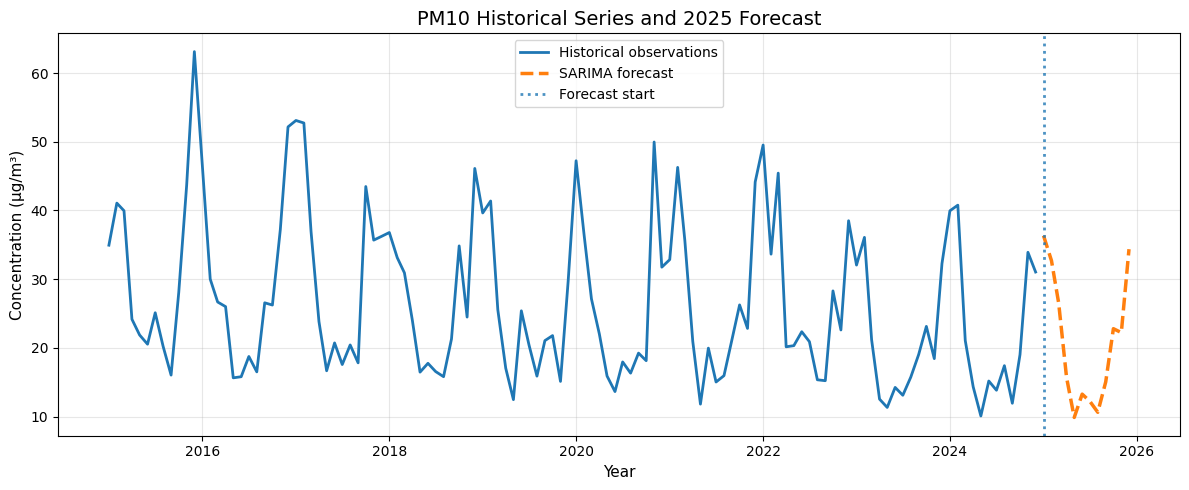

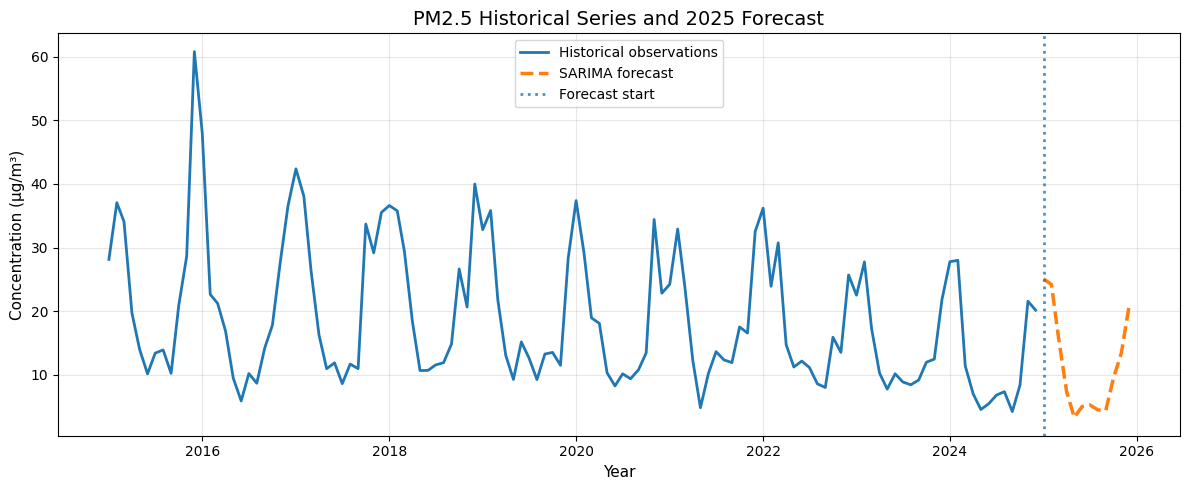

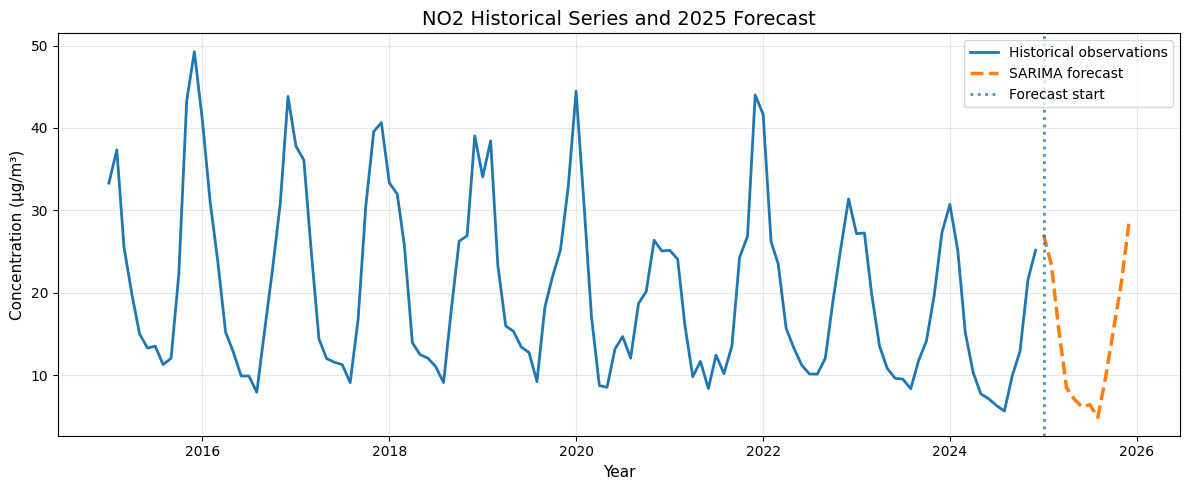

In [65]:
for pollutant in pollutants:

    plt.figure(figsize=(12, 5))

    # Historical monthly observations
    plt.plot(
        forecast_series[pollutant],
        label="Historical observations",
        linewidth=2
    )

    # SARIMA forecast for 2025
    plt.plot(
        final_forecasts[pollutant],
        label="SARIMA forecast",
        linewidth=2.5,
        linestyle="--"
    )

    # Vertical line separating historical data from forecast period
    plt.axvline(
        x=pd.Timestamp("2025-01-01"),
        linestyle=":",
        linewidth=2,
        alpha=0.8,
        label="Forecast start"
    )

    plt.title(
        f"{pollutant} Historical Series and 2025 Forecast",
        fontsize=14
    )

    plt.xlabel(
        "Year",
        fontsize=11
    )

    plt.ylabel(
        "Concentration (µg/m³)",
        fontsize=11
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## **4.9 Interpretation of Forecast Results**

The SARIMA forecasts indicate that all three pollutants are expected to preserve their historical seasonal behaviour during 2025.

Higher concentrations are forecast during the winter months (January–March and November–December), while the lowest concentrations are expected during late spring and summer. This pattern is consistent with the historical observations and can be explained by seasonal meteorological conditions together with changes in heating demand, atmospheric dispersion, and traffic emissions.

No substantial long-term increase or decrease is predicted during the forecast horizon, suggesting that pollutant concentrations are expected to remain relatively stable while maintaining their seasonal variability.

In [66]:
forecast_table = final_forecast_df.round(2)

forecast_table

,PM10,PM2.5,NO2
Month,,,
2025-01-01,36.33,25.07,27.08
2025-02-01,32.70,24.18,23.37
2025-03-01,26.56,15.71,15.66
2025-04-01,15.69,7.38,8.48
2025-05-01,9.89,3.28,7.11
2025-06-01,13.28,5.00,6.16
2025-07-01,12.23,5.24,6.44
2025-08-01,10.64,4.47,4.89
2025-09-01,15.05,4.33,9.81


In [67]:
final_forecasts_2030 = {}

for pollutant in pollutants:

    series = forecast_series[pollutant]

    model = SARIMAX(
        series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False
    )

    forecast = fitted_model.forecast(
        steps=72
    )

    forecast = np.maximum(
        forecast,
        0
    )

    final_forecasts_2030[pollutant] = forecast

In [68]:
forecast_2030_df = pd.DataFrame({
    pollutant: final_forecasts_2030[pollutant].values
    for pollutant in pollutants
})

forecast_2030_df.index = pd.date_range(
    start="2025-01-01",
    periods=72,
    freq="MS"
)

forecast_2030_df.index.name = "Month"

forecast_2030_df.round(2)

,PM10,PM2.5,NO2
Month,,,
2025-01-01,36.33,25.07,27.08
2025-02-01,32.70,24.18,23.37
2025-03-01,26.56,15.71,15.66
2025-04-01,15.69,7.38,8.48
2025-05-01,9.89,3.28,7.11
...,...,...,...
2030-08-01,7.73,0.00,0.00
2030-09-01,10.41,0.00,4.62
2030-10-01,18.04,2.14,9.98


In [69]:
annual_forecast = (
    forecast_2030_df
    .groupby(forecast_2030_df.index.year)
    .mean()
)

annual_forecast.index.name = "Year"

annual_forecast = annual_forecast.round(2)

annual_forecast

,PM10,PM2.5,NO2
Year,,,
2025,20.98,11.51,14.52
2026,20.33,10.08,13.72
2027,19.51,8.68,12.67
2028,18.72,7.36,11.66
2029,17.93,6.37,10.63
2030,17.14,5.55,9.63


## 4.10 Compliance with the 2030 EU Air Quality Limits

The annual mean forecasts were compared with the limit values established by Directive (EU) 2024/2881, which will apply from 2030.

| Pollutant | Forecast annual mean (2030) | EU 2030 limit (µg/m³) | Compliance |
|-----------|----------------------------:|----------------------:|:----------:|
| PM10 | 17.14 | 20 | ✓ Yes |
| PM2.5 | 5.55 | 10 | ✓ Yes |
| NO₂ | 9.63 | 20 | ✓ Yes |

According to the SARIMA forecasts, the annual mean concentrations of all three pollutants remain below the future EU limit values. Therefore, based on the available historical observations, this monitoring station is expected to comply with the 2030 air quality standards.

## 4.11 Limitations of the Forecast

Although the SARIMA model provides accurate short-term forecasts and performed best during the rolling-origin backtest, forecasts extending to 2030 should be interpreted with caution.

The model assumes that historical temporal patterns, seasonal behaviour, and long-term trends will continue in the future. In reality, future pollutant concentrations may be affected by factors that are not represented in the historical data, including new environmental policies, technological improvements, changes in traffic intensity, industrial activity, meteorological variability, or modifications to monitoring instruments.

Consequently, the forecasts should be considered as projections based on historical patterns rather than precise predictions of future air quality.

In [70]:
forecast_2030_df.to_parquet(
    "data/forecasts.parquet",
    index=True
)

In [71]:
import os

os.makedirs("data", exist_ok=True)

monthly_data.to_parquet("data/monthly_data.parquet", index=False)

all_results.to_parquet("data/model_metrics.parquet", index=False)

forecast_2030_df.to_parquet("data/forecasts.parquet")

annual_forecast.to_parquet("data/annual_forecast.parquet")

---
# 🖥 Task 3 — Streamlit dashboard with legal reference thresholds

Build an interactive **Streamlit** app (a separate `app.py`, or a small `app/` package) that presents your results to a non-technical audience (e.g. a municipal environment office).

### Legal thresholds to embed in the dashboard

Use these values as reference lines / KPI targets. All values are **annual means** in µg/m³ unless stated otherwise:

| Pollutant | Directive 2008/50/EC (in force) | Directive (EU) 2024/2881 — limit by 2030 | WHO 2021 guideline |
|---|---|---|---|
| **PM2.5** (annual mean) | 25 | **10** | 5 |
| **PM10** (annual mean) | 40 | **20** | 15 |
| **PM10** (daily mean) | 50, max 35 exceedances/year | 45, max 18 exceedances/year | 45 (3–4 exceedances) |
| **NO₂** (annual mean) | 40 | **20** | 10 |

### Minimum required features

1. **Overview / KPI page**
2. **Time series explorer**
4. **Forecast page**

In [136]:
!pip install streamlit plotly pyarrow

In [137]:
import pandas as pd

monthly_check = pd.read_parquet("data/monthly_data.parquet")
metrics_check = pd.read_parquet("data/model_metrics.parquet")
forecast_check = pd.read_parquet("data/forecasts.parquet")
annual_check = pd.read_parquet("data/annual_forecast.parquet")

print("monthly_data:")
print(monthly_check.shape)
print(monthly_check.columns.tolist())

print("\nmodel_metrics:")
print(metrics_check.shape)
print(metrics_check.columns.tolist())

print("\nforecasts:")
print(forecast_check.shape)
print(forecast_check.columns.tolist())
print("Index:", forecast_check.index.name, forecast_check.index.dtype)

print("\nannual_forecast:")
print(annual_check.shape)
print(annual_check.columns.tolist())
print("Index:", annual_check.index.name, annual_check.index.dtype)

monthly_data:
(396, 4)
['pollutant', 'month', 'monthly_mean', 'observations']

model_metrics:
(12, 5)
['Pollutant', 'Model', 'MAE', 'RMSE', 'sMAPE']

forecasts:
(72, 3)
['PM10', 'PM2.5', 'NO2']
Index: Month datetime64[ns]

annual_forecast:
(6, 3)
['PM10', 'PM2.5', 'NO2']
Index: Year int32


In [138]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


# --------------------------------------------------
# Page configuration
# --------------------------------------------------
st.set_page_config(
    page_title="Air Quality Forecast Dashboard",
    page_icon="🌍",
    layout="wide"
)


# --------------------------------------------------
# Load data
# --------------------------------------------------
@st.cache_data
def load_data():
    monthly_data = pd.read_parquet("data/monthly_data.parquet")
    model_metrics = pd.read_parquet("data/model_metrics.parquet")
    forecasts = pd.read_parquet("data/forecasts.parquet")
    annual_forecast = pd.read_parquet("data/annual_forecast.parquet")

    monthly_data["month"] = pd.to_datetime(monthly_data["month"])
    forecasts.index = pd.to_datetime(forecasts.index)

    return monthly_data, model_metrics, forecasts, annual_forecast


monthly_data, model_metrics, forecasts, annual_forecast = load_data()


# --------------------------------------------------
# Sidebar navigation
# --------------------------------------------------
st.sidebar.title("Navigation")

page = st.sidebar.radio(
    "Select a page",
    [
        "Overview",
        "Time Series Explorer",
        "Model Comparison",
        "Forecast to 2030"
    ]
)


# --------------------------------------------------
# Main title
# --------------------------------------------------
st.title("🌍 Air Quality Forecast Dashboard")

st.caption(
    "Historical analysis and forecasting of PM10, PM2.5 and NO₂ "
    "at monitoring station IT1876A."
)


# --------------------------------------------------
# Temporary page test
# --------------------------------------------------
if page == "Overview":
    st.header("Overview")
    st.write("Overview page is working.")

elif page == "Time Series Explorer":
    st.header("Time Series Explorer")
    st.write("Time Series Explorer page is working.")

elif page == "Model Comparison":
    st.header("Model Comparison")
    st.write("Model Comparison page is working.")

elif page == "Forecast to 2030":
    st.header("Forecast to 2030")
    st.write("Forecast page is working.")

Overwriting app.py


In [139]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [140]:
!cat /content/logs.txt

In [141]:
!pip install pyngrok

In [142]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

cloudflared: Text file busy


In [143]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text()

old_overview = '''if page == "Overview":
    st.header("Overview")
    st.write("Overview page is working.")
'''

new_overview = '''if page == "Overview":
    st.header("Overview")

    st.markdown(
        """
        This dashboard presents the historical evolution and projected future
        concentrations of **PM10, PM2.5 and NO₂** at monitoring station
        **IT1876A**.

        Historical monthly data are analysed up to 2024, while the selected
        SARIMA models provide forecasts from 2025 to 2030.
        """
    )

    forecast_2030 = annual_forecast.loc[2030]

    col1, col2, col3 = st.columns(3)

    col1.metric(
        label="PM10 forecast in 2030",
        value=f"{forecast_2030['PM10']:.2f} µg/m³",
        delta=f"{forecast_2030['PM10'] - annual_forecast.loc[2025, 'PM10']:.2f} since 2025",
        delta_color="inverse"

    )

    col2.metric(
        label="PM2.5 forecast in 2030",
        value=f"{forecast_2030['PM2.5']:.2f} µg/m³",
        delta=f"{forecast_2030['PM2.5'] - annual_forecast.loc[2025, 'PM2.5']:.2f} since 2025",
        delta_color="inverse"
    )

    col3.metric(
        label="NO₂ forecast in 2030",
        value=f"{forecast_2030['NO2']:.2f} µg/m³",
        delta=f"{forecast_2030['NO2'] - annual_forecast.loc[2025, 'NO2']:.2f} since 2025",
        delta_color="inverse"
    )

    st.subheader("Compliance with 2030 EU limits")

    eu_limits = pd.Series({
        "PM10": 20.0,
        "PM2.5": 10.0,
        "NO2": 20.0
    })

    compliance = pd.DataFrame({
        "Pollutant": eu_limits.index,
        "2030 forecast (µg/m³)": [
            forecast_2030["PM10"],
            forecast_2030["PM2.5"],
            forecast_2030["NO2"]
        ],
        "EU 2030 limit (µg/m³)": eu_limits.values
    })

    compliance["Difference from limit"] = (
        compliance["2030 forecast (µg/m³)"]
        - compliance["EU 2030 limit (µg/m³)"]
    )

    compliance["Status"] = compliance["Difference from limit"].apply(
        lambda value: "Meets target" if value <= 0 else "Above limit"
    )

    st.dataframe(
        compliance.style.format({
            "2030 forecast (µg/m³)": "{:.2f}",
            "EU 2030 limit (µg/m³)": "{:.2f}",
            "Difference from limit": "{:.2f}"
        }),
        use_container_width=True,
        hide_index=True
    )

    st.success(
        "According to the forecasts, all three pollutants are expected "
        "to comply with the selected 2030 EU concentration limits."
    )
'''

if old_overview not in app_code:
    raise ValueError(
        'The simple Overview section was not found in app.py.'
    )

updated_code = app_code.replace(old_overview, new_overview, 1)
app_path.write_text(updated_code)

print("Full Overview page added successfully.")

Full Overview page added successfully.


In [144]:
from pathlib import Path

app_path = Path("app.py")

print("File exists:", app_path.exists())
print("File size:", app_path.stat().st_size, "bytes")

app_code = app_path.read_text(encoding="utf-8")

print("File read successfully.")
print(app_code[-1000:])

File exists: True
File size: 4500 bytes
File read successfully.
(µg/m³)"]
        - compliance["EU 2030 limit (µg/m³)"]
    )

    compliance["Status"] = compliance["Difference from limit"].apply(
        lambda value: "Meets target" if value <= 0 else "Above limit"
    )

    st.dataframe(
        compliance.style.format({
            "2030 forecast (µg/m³)": "{:.2f}",
            "EU 2030 limit (µg/m³)": "{:.2f}",
            "Difference from limit": "{:.2f}"
        }),
        use_container_width=True,
        hide_index=True
    )

    st.success(
        "According to the forecasts, all three pollutants are expected "
        "to comply with the selected 2030 EU concentration limits."
    )

elif page == "Time Series Explorer":
    st.header("Time Series Explorer")
    st.write("Time Series Explorer page is working.")

elif page == "Model Comparison":
    st.header("Model Comparison")
    st.write("Model Comparison page is working.")

elif page == "Forecast to 2030":
    st.heade

In [145]:
import subprocess
import time

subprocess.run(
    ["pkill", "-f", "streamlit"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

streamlit_process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT
)

time.sleep(3)

print("Streamlit restarted successfully.")

Streamlit restarted successfully.


In [146]:
import subprocess
import time
import re

cloudflare_process = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

tunnel_url = None

for _ in range(30):
    line = cloudflare_process.stdout.readline()

    if line:
        match = re.search(
            r"https://[a-zA-Z0-9-]+\.trycloudflare\.com",
            line
        )

        if match:
            tunnel_url = match.group(0)
            break

    time.sleep(1)

if tunnel_url:
    print("Dashboard URL:")
    print(tunnel_url)
else:
    print("The tunnel started, but the URL was not detected yet.")

Dashboard URL:
https://owns-identical-leaf-parts.trycloudflare.com


In [147]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

old_pm10 = '''    col1.metric(
        label="PM10 forecast in 2030",
        value=f"{forecast_2030['PM10']:.2f} µg/m³",
        delta=f"{forecast_2030['PM10'] - annual_forecast.loc[2025, 'PM10']:.2f} since 2025",

    )
'''

new_pm10 = '''    col1.metric(
        label="PM10 forecast in 2030",
        value=f"{forecast_2030['PM10']:.2f} µg/m³",
        delta=f"{forecast_2030['PM10'] - annual_forecast.loc[2025, 'PM10']:.2f} since 2025",
        delta_color="inverse"
    )
'''

old_pm25 = '''    col2.metric(
        label="PM2.5 forecast in 2030",
        value=f"{forecast_2030['PM2.5']:.2f} µg/m³",
        delta=f"{forecast_2030['PM2.5'] - annual_forecast.loc[2025, 'PM2.5']:.2f} since 2025"
    )
'''

new_pm25 = '''    col2.metric(
        label="PM2.5 forecast in 2030",
        value=f"{forecast_2030['PM2.5']:.2f} µg/m³",
        delta=f"{forecast_2030['PM2.5'] - annual_forecast.loc[2025, 'PM2.5']:.2f} since 2025",
        delta_color="inverse"
    )
'''

old_no2 = '''    col3.metric(
        label="NO₂ forecast in 2030",
        value=f"{forecast_2030['NO2']:.2f} µg/m³",
        delta=f"{forecast_2030['NO2'] - annual_forecast.loc[2025, 'NO2']:.2f} since 2025"
    )
'''

new_no2 = '''    col3.metric(
        label="NO₂ forecast in 2030",
        value=f"{forecast_2030['NO2']:.2f} µg/m³",
        delta=f"{forecast_2030['NO2'] - annual_forecast.loc[2025, 'NO2']:.2f} since 2025",
        delta_color="inverse"
    )
'''

replacements = [
    (old_pm10, new_pm10),
    (old_pm25, new_pm25),
    (old_no2, new_no2)
]

for old, new in replacements:
    if old in app_code:
        app_code = app_code.replace(old, new, 1)

app_path.write_text(app_code, encoding="utf-8")

print("Metric delta colours updated successfully.")

Metric delta colours updated successfully.


In [148]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

lines = app_code.splitlines()

for line_number, line in enumerate(lines, start=1):
    if (
        "Time Series" in line
        or "Explorer" in line
        or "page ==" in line
        or "sidebar" in line
    ):
        start = max(0, line_number - 3)
        end = min(len(lines), line_number + 5)

        print(f"\n--- Around line {line_number} ---")
        for i in range(start, end):
            print(f"{i + 1:>3}: {lines[i]}")


--- Around line 40 ---
 38: # Sidebar navigation
 39: # --------------------------------------------------
 40: st.sidebar.title("Navigation")
 41: 
 42: page = st.sidebar.radio(
 43:     "Select a page",
 44:     [
 45:         "Overview",

--- Around line 42 ---
 40: st.sidebar.title("Navigation")
 41: 
 42: page = st.sidebar.radio(
 43:     "Select a page",
 44:     [
 45:         "Overview",
 46:         "Time Series Explorer",
 47:         "Model Comparison",

--- Around line 46 ---
 44:     [
 45:         "Overview",
 46:         "Time Series Explorer",
 47:         "Model Comparison",
 48:         "Forecast to 2030"
 49:     ]
 50: )
 51: 

--- Around line 67 ---
 65: # Temporary page test
 66: # --------------------------------------------------
 67: if page == "Overview":
 68:     st.header("Overview")
 69: 
 70:     st.markdown(
 71:         """
 72:         This dashboard presents the historical evolution and projected future

--- Around line 149 ---
147:     )
148: 
149: e

In [149]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

old_time_series = '''elif page == "Time Series Explorer":
    st.header("Time Series Explorer")
    st.write("Time Series Explorer page is working.")
'''

new_time_series = '''elif page == "Time Series Explorer":
    st.header("Time Series Explorer")

    st.markdown(
        """
        Explore the monthly mean concentration of each pollutant from
        January 2015 to December 2024.
        """
    )

    selected_pollutant = st.selectbox(
        "Select a pollutant",
        ["PM10", "PM2.5", "NO2"]
    )

    pollutant_data = monthly_data[
        monthly_data["pollutant"] == selected_pollutant
    ].copy()

    pollutant_data = pollutant_data.sort_values("month")

    fig = px.line(
        pollutant_data,
        x="month",
        y="monthly_mean",
        markers=True,
        title=f"Monthly Mean Concentration of {selected_pollutant}",
        labels={
            "month": "Month",
            "monthly_mean": "Monthly mean concentration (µg/m³)"
        }
    )

    fig.update_layout(
        hovermode="x unified",
        xaxis_title="Month",
        yaxis_title="Concentration (µg/m³)"
    )

    fig.update_traces(
        hovertemplate=(
            "<b>%{x|%B %Y}</b><br>"
            "Concentration: %{y:.2f} µg/m³"
            "<extra></extra>"
        )
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Minimum monthly mean",
        f"{pollutant_data['monthly_mean'].min():.2f} µg/m³"
    )

    col2.metric(
        "Average monthly mean",
        f"{pollutant_data['monthly_mean'].mean():.2f} µg/m³"
    )

    col3.metric(
        "Maximum monthly mean",
        f"{pollutant_data['monthly_mean'].max():.2f} µg/m³"
    )
'''

if old_time_series not in app_code:
    raise ValueError(
        "The simple Time Series Explorer section was not found in app.py."
    )

app_code = app_code.replace(
    old_time_series,
    new_time_series,
    1
)

app_path.write_text(
    app_code,
    encoding="utf-8"
)

print("Time Series Explorer page updated successfully.")

Time Series Explorer page updated successfully.


In [150]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

old_forecast = '''elif page == "Forecast to 2030":
    st.header("Forecast to 2030")
    st.write("Forecast page is working.")
'''

new_forecast = '''elif page == "Forecast to 2030":
    st.header("Forecast to 2030")

    st.markdown(
        """
        Compare the historical monthly concentrations with the SARIMA forecasts
        from January 2025 to December 2030.
        """
    )

    selected_pollutant = st.selectbox(
        "Select a pollutant",
        ["PM10", "PM2.5", "NO2"],
        key="forecast_pollutant"
    )

    historical_data = monthly_data[
        monthly_data["pollutant"] == selected_pollutant
    ].copy()

    historical_data = historical_data.sort_values("month")

    forecast_data = forecasts[
        [selected_pollutant]
    ].reset_index()

    forecast_data.columns = [
        "month",
        "forecast"
    ]

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=historical_data["month"],
            y=historical_data["monthly_mean"],
            mode="lines",
            name="Historical",
            line=dict(width=2),
            hovertemplate=(
                "<b>%{x|%B %Y}</b><br>"
                "Historical: %{y:.2f} µg/m³"
                "<extra></extra>"
            )
        )
    )

    fig.add_trace(
        go.Scatter(
            x=forecast_data["month"],
            y=forecast_data["forecast"],
            mode="lines",
            name="Forecast",
            line=dict(width=3, dash="dash"),
            hovertemplate=(
                "<b>%{x|%B %Y}</b><br>"
                "Forecast: %{y:.2f} µg/m³"
                "<extra></extra>"
            )
        )
    )

    fig.add_vline(
        x=pd.Timestamp("2025-01-01").timestamp() * 1000,
        line_dash="dot",
        annotation_text="Forecast begins",
        annotation_position="top"
    )

    fig.update_layout(
        title=f"Historical and Forecast Concentrations of {selected_pollutant}",
        xaxis_title="Month",
        yaxis_title="Concentration (µg/m³)",
        hovermode="x unified",
        legend_title="Series"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    eu_limits = {
        "PM10": 20,
        "PM2.5": 10,
        "NO2": 20
    }

    forecast_2030_value = annual_forecast.loc[
        2030,
        selected_pollutant
    ]

    eu_limit = eu_limits[selected_pollutant]

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "2030 forecast",
        f"{forecast_2030_value:.2f} µg/m³"
    )

    col2.metric(
        "2030 EU limit",
        f"{eu_limit:.2f} µg/m³"
    )

    difference = forecast_2030_value - eu_limit

    col3.metric(
        "Difference from EU limit",
        f"{difference:.2f} µg/m³",
        delta=f"{difference:.2f} µg/m³",
        delta_color="inverse"
    )

    if forecast_2030_value <= eu_limit:
        st.success(
            f"The 2030 forecast for {selected_pollutant} is below the EU limit."
        )
    else:
        st.warning(
            f"The 2030 forecast for {selected_pollutant} remains above the EU limit."
        )
'''

if old_forecast not in app_code:
    raise ValueError(
        "The simple Forecast to 2030 section was not found in app.py."
    )

app_code = app_code.replace(
    old_forecast,
    new_forecast,
    1
)

app_path.write_text(
    app_code,
    encoding="utf-8"
)

print("Forecast to 2030 page updated successfully.")

Forecast to 2030 page updated successfully.


In [151]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

old_model_comparison = '''elif page == "Model Comparison":
    st.header("Model Comparison")
    st.write("Model Comparison page is working.")
'''

new_model_comparison = '''elif page == "Model Comparison":
    st.header("Model Comparison")

    st.markdown(
        """
        Compare the forecasting performance of the evaluated models using
        MAE, RMSE and sMAPE. Lower values indicate better predictive accuracy.
        """
    )

    selected_pollutant = st.selectbox(
        "Select a pollutant",
        ["PM10", "PM2.5", "NO2"],
        key="model_comparison_pollutant"
    )

    pollutant_metrics = model_metrics[
        model_metrics["Pollutant"] == selected_pollutant
    ].copy()

    pollutant_metrics = pollutant_metrics.sort_values("RMSE")

    best_model = pollutant_metrics.iloc[0]

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Best model",
        best_model["Model"]
    )

    col2.metric(
        "Best MAE",
        f"{best_model['MAE']:.2f}"
    )

    col3.metric(
        "Best RMSE",
        f"{best_model['RMSE']:.2f}"
    )

    col4.metric(
        "Best sMAPE",
        f"{best_model['sMAPE']:.2f}%"
    )

    st.subheader("Performance metrics")

    display_metrics = pollutant_metrics[
        ["Model", "MAE", "RMSE", "sMAPE"]
    ].copy()

    display_metrics["MAE"] = display_metrics["MAE"].round(2)
    display_metrics["RMSE"] = display_metrics["RMSE"].round(2)
    display_metrics["sMAPE"] = display_metrics["sMAPE"].round(2)

    st.dataframe(
        display_metrics,
        use_container_width=True,
        hide_index=True
    )

    metrics_long = pollutant_metrics.melt(
        id_vars="Model",
        value_vars=["MAE", "RMSE", "sMAPE"],
        var_name="Metric",
        value_name="Value"
    )

    fig = px.bar(
        metrics_long,
        x="Model",
        y="Value",
        color="Metric",
        barmode="group",
        title=f"Model Performance Comparison for {selected_pollutant}",
        labels={
            "Value": "Error value",
            "Model": "Forecasting model"
        }
    )

    fig.update_layout(
        xaxis_title="Forecasting model",
        yaxis_title="Error value",
        legend_title="Metric"
    )

    fig.update_traces(
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Value: %{y:.2f}"
            "<extra></extra>"
        )
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.success(
        f"{best_model['Model']} achieved the lowest RMSE for "
        f"{selected_pollutant} and was selected as the final forecasting model."
    )
'''

if old_model_comparison not in app_code:
    raise ValueError(
        "The simple Model Comparison section was not found in app.py."
    )

app_code = app_code.replace(
    old_model_comparison,
    new_model_comparison,
    1
)

app_path.write_text(
    app_code,
    encoding="utf-8"
)

print("Model Comparison page updated successfully.")

Model Comparison page updated successfully.


In [152]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

old = '''    pollutant_metrics = pollutant_metrics.sort_values("RMSE")

    best_model = pollutant_metrics.iloc[0]
'''

new = '''    pollutant_metrics = pollutant_metrics.sort_values("RMSE")

    final_models = {
        "PM10": "SARIMA",
        "PM2.5": "SARIMA",
        "NO2": "SARIMA"
    }

    best_model = pollutant_metrics[
        pollutant_metrics["Model"] == final_models[selected_pollutant]
    ].iloc[0]
'''

if old not in app_code:
    raise ValueError("Target code not found.")

app_code = app_code.replace(old, new, 1)

old_message = '''    st.success(
        f"{best_model['Model']} achieved the lowest RMSE for "
        f"{selected_pollutant} and was selected as the final forecasting model."
    )
'''

new_message = '''    st.success(
        f"SARIMA was selected as the final forecasting model for "
        f"{selected_pollutant} after comparing all candidate models."
    )
'''

app_code = app_code.replace(old_message, new_message, 1)

app_path.write_text(app_code, encoding="utf-8")

print("Model Comparison updated successfully.")

Model Comparison updated successfully.


In [153]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

old = '''    fig.update_layout(
        hovermode="x unified",
        xaxis_title="Month",
        yaxis_title="Concentration (µg/m³)"
    )
'''

new = '''    fig.update_layout(
        hovermode="x unified",
        xaxis_title="Month",
        yaxis_title="Concentration (µg/m³)",
        xaxis=dict(
            range=[
                pd.Timestamp("2015-01-01"),
                pd.Timestamp("2024-12-31")
            ]
        )
    )
'''

app_code = app_code.replace(old, new, 1)

old2 = '''    fig.update_layout(
        title=f"Historical and Forecast Concentrations of {selected_pollutant}",
        xaxis_title="Month",
        yaxis_title="Concentration (µg/m³)",
        hovermode="x unified",
        legend_title="Series"
    )
'''

new2 = '''    fig.update_layout(
        title=f"Historical Monthly Mean and Forecast (2015–2030)",
        xaxis_title="Month",
        yaxis_title="Concentration (µg/m³)",
        hovermode="x unified",
        legend_title="Series",
        xaxis=dict(
            range=[
                pd.Timestamp("2015-01-01"),
                pd.Timestamp("2030-12-31")
            ]
        )
    )
'''

app_code = app_code.replace(old2, new2, 1)

app_path.write_text(app_code, encoding="utf-8")

print("Time axis updated.")

Time axis updated.


In [154]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

old_selectbox_block = '''    selected_pollutant = st.selectbox(
        "Select a pollutant",
        ["PM10", "PM2.5", "NO2"]
    )

    pollutant_data = monthly_data[
'''

new_selectbox_block = '''    selected_pollutant = st.selectbox(
        "Select a pollutant",
        ["PM10", "PM2.5", "NO2"]
    )

    pollutant_colors = {
        "PM10": "#F28E2B",
        "PM2.5": "#59A14F",
        "NO2": "#4E79A7"
    }

    pollutant_data = monthly_data[
'''

app_code = app_code.replace(
    old_selectbox_block,
    new_selectbox_block,
    1
)

old_time_series_trace = '''    fig.update_traces(
        hovertemplate=(
            "<b>%{x|%B %Y}</b><br>"
            "Concentration: %{y:.2f} µg/m³"
            "<extra></extra>"
        )
    )
'''

new_time_series_trace = '''    fig.update_traces(
        line=dict(
            color=pollutant_colors[selected_pollutant],
            width=3
        ),
        marker=dict(
            color=pollutant_colors[selected_pollutant],
            size=5
        ),
        hovertemplate=(
            "<b>%{x|%B %Y}</b><br>"
            "Concentration: %{y:.2f} µg/m³"
            "<extra></extra>"
        )
    )
'''

app_code = app_code.replace(
    old_time_series_trace,
    new_time_series_trace,
    1
)

old_historical_line = '''            line=dict(width=2),
'''

new_historical_line = '''            line=dict(
                width=2,
                color=pollutant_colors[selected_pollutant]
            ),
'''

app_code = app_code.replace(
    old_historical_line,
    new_historical_line,
    1
)

old_forecast_line = '''            line=dict(width=3, dash="dash"),
'''

new_forecast_line = '''            line=dict(
                width=3,
                dash="dash",
                color=pollutant_colors[selected_pollutant]
            ),
'''

app_code = app_code.replace(
    old_forecast_line,
    new_forecast_line,
    1
)

app_path.write_text(app_code, encoding="utf-8")

print("Pollutant colours updated successfully.")

Pollutant colours updated successfully.


In [155]:
from pathlib import Path

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

old = '''    selected_pollutant = st.selectbox(
        "Select a pollutant",
        ["PM10", "PM2.5", "NO2"],
        key="forecast_pollutant"
    )

    historical_data = monthly_data[
'''

new = '''    selected_pollutant = st.selectbox(
        "Select a pollutant",
        ["PM10", "PM2.5", "NO2"],
        key="forecast_pollutant"
    )

    pollutant_colors = {
        "PM10": "#F28E2B",
        "PM2.5": "#59A14F",
        "NO2": "#4E79A7"
    }

    historical_data = monthly_data[
'''

if old not in app_code:
    raise ValueError(
        "Forecast selectbox section was not found in app.py."
    )

app_code = app_code.replace(old, new, 1)

app_path.write_text(app_code, encoding="utf-8")

print("Forecast pollutant colours fixed successfully.")

Forecast pollutant colours fixed successfully.
